In [3]:
# 폰트 설치
!sudo apt-get install -y fonts-nanum*
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'fonts-nanum-extra' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-coding' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-eco' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum' for glob 'fonts-nanum*'
fonts-nanum is already the newest version (20200506-1).
fonts-nanum-coding is already the newest version (2.5-3).
fonts-nanum-eco is already the newest version (1.000-7).
fonts-nanum-extra is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts,

In [1]:
import matplotlib as mpl

# 한글 폰트 설정
mpl.rc('font', family='NanumGothic')
mpl.rcParams['axes.unicode_minus'] = False

In [2]:
import pandas as pd
import numpy as np

# 데이터 불러오기

In [6]:
# A 물류센터
purchase_A = pd.read_excel('A물류센터 매입 2021~2024 배포용.xlsx')
sales_A = pd.read_excel('A물류센터 매출 2021~2023 배포용.xlsx')
sales_A_2024 = pd.read_excel('A물류센터 매출 2024 배포용.xlsx')

# B 물류센터
purchase_B = pd.read_excel('B물류센터 매입 2021~2024 배포용.xlsx')

# 필터링

### A매입(2021~2024)

In [7]:
#====필요 칼럼만 선택====
purchase_A_cols = [
    "일자", "작업유형",
    "수량", "판매금액", "중분류", "공급업체 우편번호", "부가세(과세)"
]

purchase_A = purchase_A[purchase_A['작업유형'] == '입고'][purchase_A_cols]

purchase_A.head()

,일자,작업유형,수량,판매금액,중분류,공급업체 우편번호,부가세(과세)
0,2021-01-05,입고,5,68100,"생수,음료,건강",37899,6810
1,2021-01-05,입고,10,109000,"생수,음료,건강",37899,10900
2,2021-01-05,입고,10,109000,"생수,음료,건강",37899,10900
3,2021-01-05,입고,20,310900,"생수,음료,건강",37899,31090
4,2021-01-05,입고,20,509000,"생수,음료,건강",37899,50900


In [8]:
#====날짜/연도/월/요일 컬럼 생성====
purchase_A["일자"] = pd.to_datetime(purchase_A["일자"], errors="coerce")
purchase_A["연도"] = purchase_A["일자"].dt.year.astype(int)
purchase_A["월"] = purchase_A["일자"].dt.month.astype(int)
purchase_A["일"] = purchase_A["일자"].dt.day.astype(int)
purchase_A["요일"] = purchase_A["일자"].dt.day_name()

In [9]:
#====계절 함수 생성====
def get_season(month):
  if month in [12,1,2]:
    return '겨울'
  elif month in [3,4,5]:
    return '봄'
  elif month in [6,7,8]:
    return '여름'
  else:
    return '가을'

purchase_A['계절'] = purchase_A['월'].apply(get_season)

In [10]:
purchase_A.head()

,일자,작업유형,수량,판매금액,중분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절
0,2021-01-05,입고,5,68100,"생수,음료,건강",37899,6810,2021,1,5,Tuesday,겨울
1,2021-01-05,입고,10,109000,"생수,음료,건강",37899,10900,2021,1,5,Tuesday,겨울
2,2021-01-05,입고,10,109000,"생수,음료,건강",37899,10900,2021,1,5,Tuesday,겨울
3,2021-01-05,입고,20,310900,"생수,음료,건강",37899,31090,2021,1,5,Tuesday,겨울
4,2021-01-05,입고,20,509000,"생수,음료,건강",37899,50900,2021,1,5,Tuesday,겨울


In [11]:
purchase_A.info()

<class 'pandas.core.frame.DataFrame'>
Index: 201534 entries, 0 to 227467
Data columns (total 12 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   일자         201534 non-null  datetime64[ns]
 1   작업유형       201534 non-null  object        
 2   수량         201534 non-null  int64         
 3   판매금액       201534 non-null  int64         
 4   중분류        199689 non-null  object        
 5   공급업체 우편번호  201534 non-null  int64         
 6   부가세(과세)    201534 non-null  int64         
 7   연도         201534 non-null  int64         
 8   월          201534 non-null  int64         
 9   일          201534 non-null  int64         
 10  요일         201534 non-null  object        
 11  계절         201534 non-null  object        
dtypes: datetime64[ns](1), int64(7), object(4)
memory usage: 20.0+ MB


#### 시군구 수동 mapping

In [12]:
#====공급업체 시/시군 필터링====
def add_region_codes(df):
    df["공급업체_시"] = df["공급업체 우편번호"].astype(str).str[:2]
    return df

purchase_A = add_region_codes(purchase_A)

In [13]:
purchase_A["공급업체_시"].unique()

array(['37', '41', '10', '14', '47', '21', '33', '65', '50', '26', '44',
       '66', '42', '61', '72', '38', '45', '39', '85', '31', '79', '67',
       '20', '75', '17', '43', '73', '18', '16', '32', '40', '77', '12',
       '46', '36', '56', '11', '82', '30', '62', '57', '24'], dtype=object)

In [14]:
#====시군 코드 딕셔너리 생성====
si_dict = {
    "10": "경기도",
    "14": "경기도",
    "39": "경상북도",
    "37": "경상북도",
    "04": "서울특별시",
    "41": "대구광역시",
    "44": "울산광역시",
    "47": "부산광역시",
    "50": "경상남도",
    "07": "서울특별시",
    "43": "대구광역시",
    "32": "충청남도",
    "38": "경상북도",
    "06": "서울특별시",
    "56": "전북특별자치도",
    "46": "부산광역시",
    "21": "인천광역시",
    "03":"서울특별시",
    "26":"강원특별자치도",
    "42":"대구광역시",
    "08":"서울특별시",
    "31":"충청남도",
    "02":"서울특별시",
    "17":"경기도",
    "01":"서울특별시",
    "16":"경기도",
    "12":"경기도",
    "40":"경상북도",
    "18":"경기도",
    "11":"경기도",
    "30":"세종특별자치시",
    "62":"광주광역시",
    "05":"서울특별시",
    "24":"강원특별자치도"
}

In [15]:
purchase_A["공급업체_시"] = purchase_A["공급업체_시"].map(si_dict)

#### 필터링 수행

In [16]:
#====중분류 신선식품/생수,음료,건강 필터링====
purchase_A_fresh = purchase_A[purchase_A["중분류"] == "신선식품"].copy()
purchase_A_drinks = purchase_A[purchase_A["중분류"] == "생수,음료,건강"].copy()

In [17]:
purchase_A_fresh.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8245 entries, 546 to 227448
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   일자         8245 non-null   datetime64[ns]
 1   작업유형       8245 non-null   object        
 2   수량         8245 non-null   int64         
 3   판매금액       8245 non-null   int64         
 4   중분류        8245 non-null   object        
 5   공급업체 우편번호  8245 non-null   int64         
 6   부가세(과세)    8245 non-null   int64         
 7   연도         8245 non-null   int64         
 8   월          8245 non-null   int64         
 9   일          8245 non-null   int64         
 10  요일         8245 non-null   object        
 11  계절         8245 non-null   object        
 12  공급업체_시     8245 non-null   object        
dtypes: datetime64[ns](1), int64(7), object(5)
memory usage: 901.8+ KB


In [18]:
purchase_A_drinks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19971 entries, 0 to 227343
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   일자         19971 non-null  datetime64[ns]
 1   작업유형       19971 non-null  object        
 2   수량         19971 non-null  int64         
 3   판매금액       19971 non-null  int64         
 4   중분류        19971 non-null  object        
 5   공급업체 우편번호  19971 non-null  int64         
 6   부가세(과세)    19971 non-null  int64         
 7   연도         19971 non-null  int64         
 8   월          19971 non-null  int64         
 9   일          19971 non-null  int64         
 10  요일         19971 non-null  object        
 11  계절         19971 non-null  object        
 12  공급업체_시     15771 non-null  object        
dtypes: datetime64[ns](1), int64(7), object(5)
memory usage: 2.1+ MB


#### 데이터 추출

In [19]:
from google.colab import files

purchase_A_fresh.to_csv("purchase_A_fresh.csv", index=False)
files.download("purchase_A_fresh.csv")

purchase_A_drinks.to_csv("purchase_A_drinks.csv", index=False)
files.download("purchase_A_drinks.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### A매출(2021~2023)

In [85]:
sales_A = pd.read_excel('A물류센터 매출 2021~2023 배포용.xlsx', sheet_name=None)
print(sales_A.keys())
df1 = sales_A["Result 1"]
df2 = sales_A["Result 2"]

dict_keys(['Result 1', 'Result 2'])


In [86]:
sales_A = pd.concat([df1, df2], ignore_index=True)

In [87]:
# 필요 칼럼만 선택
sales_A_cols = ['판매일', '구분', '매출처 우편번호', '판매수량', '중분류', '공급금액', '부가세(과세)']
sales_A = sales_A[sales_A['구분'] == '매출'][sales_A_cols]

sales_A.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세)
0,2021-01-04,매출,37806,3,"라면,통조림,상온즉석",5400,540
1,2021-01-04,매출,37806,4,"라면,통조림,상온즉석",11900,1190
2,2021-01-04,매출,37806,2,"라면,통조림,상온즉석",7800,780
3,2021-01-04,매출,37806,3,"라면,통조림,상온즉석",5600,560
4,2021-01-04,매출,37806,3,"라면,통조림,상온즉석",7100,710


In [88]:
# 날짜/연도/월/요일 컬럼 생성
sales_A["판매일"] = pd.to_datetime(sales_A['판매일'])
sales_A['연도'] = sales_A['판매일'].dt.year.astype(int)
sales_A['월'] = sales_A['판매일'].dt.month.astype(int)
sales_A['일'] = sales_A['판매일'].dt.day.astype(int)
sales_A['요일'] = sales_A['판매일'].dt.day_name()

In [89]:
# 계절 컬럼 생성
def get_season(month):
  if month in [12,1,2]:
    return '겨울'
  elif month in [3,4,5]:
    return '봄'
  elif month in [6,7,8]:
    return '여름'
  else:
    return '가을'

sales_A['계절'] = sales_A['월'].apply(get_season)

In [90]:
sales_A.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,요일,계절
0,2021-01-04,매출,37806,3,"라면,통조림,상온즉석",5400,540,2021,1,4,Monday,겨울
1,2021-01-04,매출,37806,4,"라면,통조림,상온즉석",11900,1190,2021,1,4,Monday,겨울
2,2021-01-04,매출,37806,2,"라면,통조림,상온즉석",7800,780,2021,1,4,Monday,겨울
3,2021-01-04,매출,37806,3,"라면,통조림,상온즉석",5600,560,2021,1,4,Monday,겨울
4,2021-01-04,매출,37806,3,"라면,통조림,상온즉석",7100,710,2021,1,4,Monday,겨울


#### 시도 수동 mapping

In [91]:
def add_region_codes(df):
    df = df.copy()
    df["매출처_시"] = df["매출처 우편번호"].astype(str).str[:2]
    return df

sales_A = add_region_codes(sales_A)

sales_A.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,요일,계절,매출처_시
0,2021-01-04,매출,37806,3,"라면,통조림,상온즉석",5400,540,2021,1,4,Monday,겨울,37
1,2021-01-04,매출,37806,4,"라면,통조림,상온즉석",11900,1190,2021,1,4,Monday,겨울,37
2,2021-01-04,매출,37806,2,"라면,통조림,상온즉석",7800,780,2021,1,4,Monday,겨울,37
3,2021-01-04,매출,37806,3,"라면,통조림,상온즉석",5600,560,2021,1,4,Monday,겨울,37
4,2021-01-04,매출,37806,3,"라면,통조림,상온즉석",7100,710,2021,1,4,Monday,겨울,37


In [92]:
sales_A['매출처_시'].unique()

array(['37', '38', '17', '50', '58', '39', '36', '44', '25', '62', '31',
       '46'], dtype=object)

In [93]:
# 시도 코드 딕셔너리 생성
si_map = {
    '37' : '경상북도',
    '38' : '경상북도',
    '39' : '경상북도',
    '50' : '경상남도',
    '17' : '경기도',
    '44' : '울산광역시',
    '36' : '경상북도',
    '62' : '광주광역시',
    '31' : '충청남도',
    '46' : '부산광역시',
    '58' : '전라남도',
    '25' : '강원특별자치도'
}

In [94]:
sales_A["매출처_시"] = sales_A["매출처_시"].map(si_map)
sales_A.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,요일,계절,매출처_시
0,2021-01-04,매출,37806,3,"라면,통조림,상온즉석",5400,540,2021,1,4,Monday,겨울,경상북도
1,2021-01-04,매출,37806,4,"라면,통조림,상온즉석",11900,1190,2021,1,4,Monday,겨울,경상북도
2,2021-01-04,매출,37806,2,"라면,통조림,상온즉석",7800,780,2021,1,4,Monday,겨울,경상북도
3,2021-01-04,매출,37806,3,"라면,통조림,상온즉석",5600,560,2021,1,4,Monday,겨울,경상북도
4,2021-01-04,매출,37806,3,"라면,통조림,상온즉석",7100,710,2021,1,4,Monday,겨울,경상북도


#### 필터링 수행

In [95]:
# 중분류 신선식품/생수,음료,건강 필터링
A_fresh = sales_A[sales_A['중분류'] == '신선식품'].copy()
A_drinks = sales_A[sales_A['중분류'] == '생수,음료,건강'].copy()

In [96]:
A_fresh.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26512 entries, 377 to 1461340
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   판매일       26512 non-null  datetime64[ns]
 1   구분        26512 non-null  object        
 2   매출처 우편번호  26512 non-null  int64         
 3   판매수량      26512 non-null  int64         
 4   중분류       26512 non-null  object        
 5   공급금액      26512 non-null  int64         
 6   부가세(과세)   26512 non-null  int64         
 7   연도        26512 non-null  int64         
 8   월         26512 non-null  int64         
 9   일         26512 non-null  int64         
 10  요일        26512 non-null  object        
 11  계절        26512 non-null  object        
 12  매출처_시     26512 non-null  object        
dtypes: datetime64[ns](1), int64(7), object(5)
memory usage: 2.8+ MB


In [97]:
A_drinks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 194569 entries, 85 to 1461339
Data columns (total 13 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   판매일       194569 non-null  datetime64[ns]
 1   구분        194569 non-null  object        
 2   매출처 우편번호  194569 non-null  int64         
 3   판매수량      194569 non-null  int64         
 4   중분류       194569 non-null  object        
 5   공급금액      194569 non-null  int64         
 6   부가세(과세)   194569 non-null  int64         
 7   연도        194569 non-null  int64         
 8   월         194569 non-null  int64         
 9   일         194569 non-null  int64         
 10  요일        194569 non-null  object        
 11  계절        194569 non-null  object        
 12  매출처_시     194569 non-null  object        
dtypes: datetime64[ns](1), int64(7), object(5)
memory usage: 20.8+ MB


#### 데이터셋 추출

In [98]:
from google.colab import files
A_fresh.to_csv("sales_A_fresh.csv", index=False)
files.download("sales_A_fresh.csv")

A_drinks.to_csv("sales_A_drinks.csv", index=False)
files.download("sales_A_drinks.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [99]:
sales_A_fresh = pd.read_csv("sales_A_fresh.csv")
sales_A_fresh.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,요일,계절,매출처_시
0,2021-01-04,매출,37791,1,신선식품,33000,3300,2021,1,4,Monday,겨울,경상북도
1,2021-01-04,매출,37842,3,신선식품,86900,8690,2021,1,4,Monday,겨울,경상북도
2,2021-01-04,매출,37902,4,신선식품,14500,1450,2021,1,4,Monday,겨울,경상북도
3,2021-01-04,매출,38854,3,신선식품,78400,7840,2021,1,4,Monday,겨울,경상북도
4,2021-01-04,매출,37788,1,신선식품,33000,3300,2021,1,4,Monday,겨울,경상북도


In [100]:
sales_A_drinks = pd.read_csv("sales_A_drinks.csv")
sales_A_drinks.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,요일,계절,매출처_시
0,2021-01-04,매출,37581,24,"생수,음료,건강",29500,2950,2021,1,4,Monday,겨울,경상북도
1,2021-01-04,매출,37581,12,"생수,음료,건강",17400,1740,2021,1,4,Monday,겨울,경상북도
2,2021-01-04,매출,37611,1,"생수,음료,건강",20100,2010,2021,1,4,Monday,겨울,경상북도
3,2021-01-04,매출,37611,5,"생수,음료,건강",19600,1960,2021,1,4,Monday,겨울,경상북도
4,2021-01-04,매출,37611,10,"생수,음료,건강",17300,1730,2021,1,4,Monday,겨울,경상북도


## A매출(2024)

In [101]:
#====필요 칼럼만 선택====
sales_A_2024_cols = [
    "판매일", "구분", "우편번호",
    "판매수량", "중분류", "공급가액", "부가세"
]

sales_A_2024 = sales_A_2024[sales_A_2024['구분'] == '매출'][sales_A_2024_cols]

sales_A_2024.head()

,판매일,구분,우편번호,판매수량,중분류,공급가액,부가세
0,2024-01-02,매출,37684,2,잡화,18500,1850
1,2024-01-02,매출,37542,1,"생수,음료,건강",16900,1690
2,2024-01-02,매출,37542,2,"과자,씨리얼,초코릿,빵류",17000,1700
3,2024-01-02,매출,37542,1,"생수,음료,건강",17400,1740
4,2024-01-02,매출,37542,1,"생수,음료,건강",10500,1050


In [102]:
#====날짜/연도/월/요일 컬럼 생성====
sales_A_2024["판매일"] = pd.to_datetime(sales_A_2024["판매일"], errors="coerce")
sales_A_2024["연도"] = sales_A_2024["판매일"].dt.year.astype(int)
sales_A_2024["월"] = sales_A_2024["판매일"].dt.month.astype(int)
sales_A_2024["일"] = sales_A_2024["판매일"].dt.day.astype(int)
sales_A_2024["요일"] = sales_A_2024["판매일"].dt.day_name()

In [103]:
#====계절 함수 생성====
def get_season(month):
  if month in [12,1,2]:
    return '겨울'
  elif month in [3,4,5]:
    return '봄'
  elif month in [6,7,8]:
    return '여름'
  else:
    return '가을'

sales_A_2024['계절'] = sales_A_2024['월'].apply(get_season)

In [104]:
sales_A_2024.head()

,판매일,구분,우편번호,판매수량,중분류,공급가액,부가세,연도,월,일,요일,계절
0,2024-01-02,매출,37684,2,잡화,18500,1850,2024,1,2,Tuesday,겨울
1,2024-01-02,매출,37542,1,"생수,음료,건강",16900,1690,2024,1,2,Tuesday,겨울
2,2024-01-02,매출,37542,2,"과자,씨리얼,초코릿,빵류",17000,1700,2024,1,2,Tuesday,겨울
3,2024-01-02,매출,37542,1,"생수,음료,건강",17400,1740,2024,1,2,Tuesday,겨울
4,2024-01-02,매출,37542,1,"생수,음료,건강",10500,1050,2024,1,2,Tuesday,겨울


In [105]:
sales_A_2024.info()

<class 'pandas.core.frame.DataFrame'>
Index: 372389 entries, 0 to 382475
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   판매일     372389 non-null  datetime64[ns]
 1   구분      372389 non-null  object        
 2   우편번호    372389 non-null  int64         
 3   판매수량    372389 non-null  int64         
 4   중분류     154621 non-null  object        
 5   공급가액    372389 non-null  int64         
 6   부가세     372389 non-null  int64         
 7   연도      372389 non-null  int64         
 8   월       372389 non-null  int64         
 9   일       372389 non-null  int64         
 10  요일      372389 non-null  object        
 11  계절      372389 non-null  object        
dtypes: datetime64[ns](1), int64(7), object(4)
memory usage: 36.9+ MB


### 시군구 수동 mapping

In [106]:
#====매출처 시/시군 필터링====
def add_region_codes(df):
    df = df.copy()
    df["매출처_시"] = df["우편번호"].astype(str).str[:2]
    return df

sales_A_2024 = add_region_codes(sales_A_2024)

In [107]:
sales_A_2024["매출처_시"].unique()

array(['37', '38', '36', '50'], dtype=object)

In [108]:
#====시군 코드 딕셔너리 생성====
si_dict = {
    "37": "경상북도",
    "38": "경상북도",
    "36": "경상북도",
    "50": "경상남도"
}

In [109]:
sales_A_2024["매출처_시"] = sales_A_2024["매출처_시"].map(si_dict)

In [110]:
sales_A_2024.head()

,판매일,구분,우편번호,판매수량,중분류,공급가액,부가세,연도,월,일,요일,계절,매출처_시
0,2024-01-02,매출,37684,2,잡화,18500,1850,2024,1,2,Tuesday,겨울,경상북도
1,2024-01-02,매출,37542,1,"생수,음료,건강",16900,1690,2024,1,2,Tuesday,겨울,경상북도
2,2024-01-02,매출,37542,2,"과자,씨리얼,초코릿,빵류",17000,1700,2024,1,2,Tuesday,겨울,경상북도
3,2024-01-02,매출,37542,1,"생수,음료,건강",17400,1740,2024,1,2,Tuesday,겨울,경상북도
4,2024-01-02,매출,37542,1,"생수,음료,건강",10500,1050,2024,1,2,Tuesday,겨울,경상북도


###필터링 수행

In [111]:
#====중분류 신선식품/생수,음료,건강 필터링====
A_sales_2024_fresh = sales_A_2024[sales_A_2024["중분류"] == "신선식품"].copy()
A_sales_2024_drinks = sales_A_2024[sales_A_2024["중분류"] == "생수,음료,건강"].copy()

In [112]:
A_sales_2024_drinks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28370 entries, 1 to 160332
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   판매일     28370 non-null  datetime64[ns]
 1   구분      28370 non-null  object        
 2   우편번호    28370 non-null  int64         
 3   판매수량    28370 non-null  int64         
 4   중분류     28370 non-null  object        
 5   공급가액    28370 non-null  int64         
 6   부가세     28370 non-null  int64         
 7   연도      28370 non-null  int64         
 8   월       28370 non-null  int64         
 9   일       28370 non-null  int64         
 10  요일      28370 non-null  object        
 11  계절      28370 non-null  object        
 12  매출처_시   28370 non-null  object        
dtypes: datetime64[ns](1), int64(7), object(5)
memory usage: 3.0+ MB


In [113]:
A_sales_2024_fresh.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6283 entries, 7 to 160338
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   판매일     6283 non-null   datetime64[ns]
 1   구분      6283 non-null   object        
 2   우편번호    6283 non-null   int64         
 3   판매수량    6283 non-null   int64         
 4   중분류     6283 non-null   object        
 5   공급가액    6283 non-null   int64         
 6   부가세     6283 non-null   int64         
 7   연도      6283 non-null   int64         
 8   월       6283 non-null   int64         
 9   일       6283 non-null   int64         
 10  요일      6283 non-null   object        
 11  계절      6283 non-null   object        
 12  매출처_시   6283 non-null   object        
dtypes: datetime64[ns](1), int64(7), object(5)
memory usage: 687.2+ KB


### 데이터셋 추출

In [114]:
from google.colab import files

A_sales_2024_drinks.to_csv("A_sales_2024_drinks.csv", index=False)
files.download("A_sales_2024_drinks.csv")

A_sales_2024_fresh.to_csv("A_sales_2024_fresh.csv", index=False)
files.download("A_sales_2024_fresh.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## B매입(2021~2024)

In [116]:
file_path = "B물류센터 매입 2021~2024 배포용.xlsx"
purchase_B = pd.read_excel(file_path, sheet_name="매입", dtype={'공급업체 우편번호': str})
purchase_B.head()

,작업유형,일자,매출처코드,매출처 우편번호,공급업체 코드,공급업체 우편번호,입고 형태,상품코드,바코드,상품명,...,옵션 코드,옵션,입수,수량,EA,판매금액,부가세(과세),대분류,중분류,소분류
0,입고,2021-01-05,NaN,NaN,300050,51247,센터에서 정상적으로 입고,18801007803187,1.880101e+13,(CJ)햇반200g*12,...,EA,낱개,1,104,104,850900,85090,가공식품류,레토르트식품,기타레토르트식품
1,입고,2021-01-05,NaN,NaN,300008,47026,센터에서 정상적으로 입고,8801037048186,8.801037e+12,(동서식품)맥심모카골드믹스20T,...,EA,낱개,1,960,960,2094500,209450,"음료,차류",음료,커피믹스
2,입고,2021-01-05,NaN,NaN,300008,47026,센터에서 정상적으로 입고,8801037088168,8.801037e+12,(동서식품)오레오화이트크림100g,...,EA,낱개,1,504,504,320700,32070,빵.케익.과자류,과자류,비스켓류
3,입고,2021-01-05,NaN,NaN,300008,47026,센터에서 정상적으로 입고,8801043014830,8.801043e+12,(농심)신라면멀티120g*5,...,EA,낱개,1,1344,1344,3436300,343630,면류.라면류,라면류,봉지라면
4,입고,2021-01-05,NaN,NaN,300008,47026,센터에서 정상적으로 입고,8886467100024,8.886467e+12,프링글스양파맛110g,...,EA,낱개,1,240,240,261800,26180,빵.케익.과자류,과자류,스낵류


In [117]:
purchase_B.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345021 entries, 0 to 345020
Data columns (total 21 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   작업유형       345021 non-null  object 
 1   일자         345021 non-null  object 
 2   매출처코드      204232 non-null  float64
 3   매출처 우편번호   204232 non-null  float64
 4   공급업체 코드    345021 non-null  int64  
 5   공급업체 우편번호  345021 non-null  object 
 6   입고 형태      345021 non-null  object 
 7   상품코드       345021 non-null  int64  
 8   바코드        344915 non-null  float64
 9   상품명        345021 non-null  object 
 10  규격         290989 non-null  object 
 11  옵션 코드      345021 non-null  object 
 12  옵션         345021 non-null  object 
 13  입수         345021 non-null  int64  
 14  수량         345021 non-null  int64  
 15  EA         345021 non-null  int64  
 16  판매금액       345021 non-null  int64  
 17  부가세(과세)    345021 non-null  int64  
 18  대분류        345016 non-null  object 
 19  중분류        111480 non-n

In [118]:
#====필요 칼럼만 선택====
purchase_B_cols = [
    "일자", "작업유형",
    "수량", "판매금액",
    "소분류", "공급업체 우편번호",
    "부가세(과세)"
]

purchase_B = purchase_B[purchase_B['작업유형'] == '입고'][purchase_B_cols]

purchase_B.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세)
0,2021-01-05,입고,104,850900,기타레토르트식품,51247,85090
1,2021-01-05,입고,960,2094500,커피믹스,47026,209450
2,2021-01-05,입고,504,320700,비스켓류,47026,32070
3,2021-01-05,입고,1344,3436300,봉지라면,47026,343630
4,2021-01-05,입고,240,261800,스낵류,47026,26180


In [119]:
#====날짜/연도/월/요일 컬럼 생성====
purchase_B["일자"] = pd.to_datetime(purchase_B["일자"], errors="coerce")
purchase_B["연도"] = purchase_B["일자"].dt.year.astype(int)
purchase_B["월"] = purchase_B["일자"].dt.month.astype(int)
purchase_B['일'] = purchase_B['일자'].dt.day.astype(int)
purchase_B["요일"] = purchase_B["일자"].dt.day_name()

In [120]:
#====계절 함수 생성====
def get_season(month):
  if month in [12,1,2]:
    return '겨울'
  elif month in [3,4,5]:
    return '봄'
  elif month in [6,7,8]:
    return '여름'
  else:
    return '가을'

purchase_B['계절'] = purchase_B['월'].apply(get_season)

In [121]:
purchase_B.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절
0,2021-01-05,입고,104,850900,기타레토르트식품,51247,85090,2021,1,5,Tuesday,겨울
1,2021-01-05,입고,960,2094500,커피믹스,47026,209450,2021,1,5,Tuesday,겨울
2,2021-01-05,입고,504,320700,비스켓류,47026,32070,2021,1,5,Tuesday,겨울
3,2021-01-05,입고,1344,3436300,봉지라면,47026,343630,2021,1,5,Tuesday,겨울
4,2021-01-05,입고,240,261800,스낵류,47026,26180,2021,1,5,Tuesday,겨울


#### 시도 수동 mapping

In [122]:
#====공급업체 시필터링====
def add_region_codes(df):
    df = df.copy()
    df["공급업체_시"] = df["공급업체 우편번호"].astype(str).str[:2]
    return df

purchase_B = add_region_codes(purchase_B)

In [123]:
purchase_B["공급업체_시"].unique()

array(['51', '47', '07', '50', '41', '52', '06', '46', '17', '16', '36',
       '05', '02', '42', '38', '49', '15', '40', '63', '48', '12', '18',
       '24', '04', '44', '08', '10', '32'], dtype=object)

In [124]:
#====시도 코드 딕셔너리 생성====
si_dict = {
    '51': '경상남도',
    '47': '부산광역시',
    '07': '서울특별시',
    '50': '경상남도',
    '41': '대구광역시',
    '52': '경상남도',
    '06': '서울특별시',
    '46': '부산광역시',
    '17': '경기도',
    '16': '경기도',
    '36': '경상북도',
    '05': '서울특별시',
    '02': '서울특별시',
    '42': '대구광역시',
    '38': '경상북도',
    '49': '부산광역시',
    '15': '경기도',
    '40': '경상북도',
    '63': '제주특별자치도',
    '48': '부산광역시',
    '12': '경기도',
    '18': '경기도',
    '24': '강원특별자치도',
    '04': '서울특별시',
    '44': '울산광역시',
    '08': '서울특별시',
    '10': '경기도',
    '32': '충청남도'
}

In [125]:
purchase_B["공급업체_시"] = purchase_B["공급업체_시"].map(si_dict)
purchase_B.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절,공급업체_시
0,2021-01-05,입고,104,850900,기타레토르트식품,51247,85090,2021,1,5,Tuesday,겨울,경상남도
1,2021-01-05,입고,960,2094500,커피믹스,47026,209450,2021,1,5,Tuesday,겨울,부산광역시
2,2021-01-05,입고,504,320700,비스켓류,47026,32070,2021,1,5,Tuesday,겨울,부산광역시
3,2021-01-05,입고,1344,3436300,봉지라면,47026,343630,2021,1,5,Tuesday,겨울,부산광역시
4,2021-01-05,입고,240,261800,스낵류,47026,26180,2021,1,5,Tuesday,겨울,부산광역시


#### 필터링 수행

In [126]:
#====소분류 탄산음료/봉지라면 필터링====
B_drinks = purchase_B[purchase_B["소분류"] == "탄산음료"].copy()
B_ramen = purchase_B[purchase_B["소분류"] == "봉지라면"].copy()

In [127]:
B_drinks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1915 entries, 6 to 344971
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   일자         1915 non-null   datetime64[ns]
 1   작업유형       1915 non-null   object        
 2   수량         1915 non-null   int64         
 3   판매금액       1915 non-null   int64         
 4   소분류        1915 non-null   object        
 5   공급업체 우편번호  1915 non-null   object        
 6   부가세(과세)    1915 non-null   int64         
 7   연도         1915 non-null   int64         
 8   월          1915 non-null   int64         
 9   일          1915 non-null   int64         
 10  요일         1915 non-null   object        
 11  계절         1915 non-null   object        
 12  공급업체_시     1915 non-null   object        
dtypes: datetime64[ns](1), int64(6), object(6)
memory usage: 209.5+ KB


In [128]:
B_ramen.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2419 entries, 3 to 345000
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   일자         2419 non-null   datetime64[ns]
 1   작업유형       2419 non-null   object        
 2   수량         2419 non-null   int64         
 3   판매금액       2419 non-null   int64         
 4   소분류        2419 non-null   object        
 5   공급업체 우편번호  2419 non-null   object        
 6   부가세(과세)    2419 non-null   int64         
 7   연도         2419 non-null   int64         
 8   월          2419 non-null   int64         
 9   일          2419 non-null   int64         
 10  요일         2419 non-null   object        
 11  계절         2419 non-null   object        
 12  공급업체_시     2419 non-null   object        
dtypes: datetime64[ns](1), int64(6), object(6)
memory usage: 264.6+ KB


### 데이터 추출

In [129]:
from google.colab import files
B_drinks.to_csv("purchase_B_drinks.csv", index=False)
files.download("purchase_B_drinks.csv")

B_ramen.to_csv("purchase_B_ramen.csv", index=False)
files.download("purchase_B_ramen.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [130]:
purchase_B_drinks=pd.read_csv("purchase_B_drinks.csv")
purchase_B_drinks.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절,공급업체_시
0,2021-01-05,입고,320,203800,탄산음료,51402,20380,2021,1,5,Tuesday,겨울,경상남도
1,2021-01-05,입고,4500,2250000,탄산음료,51402,225000,2021,1,5,Tuesday,겨울,경상남도
2,2021-01-05,입고,1152,1374900,탄산음료,50859,137490,2021,1,5,Tuesday,겨울,경상남도
3,2021-01-05,입고,132,159000,탄산음료,50859,15900,2021,1,5,Tuesday,겨울,경상남도
4,2021-01-05,입고,120,98100,탄산음료,41142,9810,2021,1,5,Tuesday,겨울,대구광역시


In [131]:
purchase_B_ramen=pd.read_csv("purchase_B_ramen.csv")
purchase_B_ramen.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절,공급업체_시
0,2021-01-05,입고,1344,3436300,봉지라면,47026,343630,2021,1,5,Tuesday,겨울,부산광역시
1,2021-01-05,입고,80,238800,봉지라면,7270,23880,2021,1,5,Tuesday,겨울,서울특별시
2,2021-01-05,입고,80,332800,봉지라면,7270,33280,2021,1,5,Tuesday,겨울,서울특별시
3,2021-01-05,입고,80,238800,봉지라면,7270,23880,2021,1,5,Tuesday,겨울,서울특별시
4,2021-01-07,입고,160,421800,봉지라면,6132,42180,2021,1,7,Thursday,겨울,서울특별시


# 외부데이터 활용 및 파생변수 생성

## A매입

In [132]:
purchase_A_fresh = pd.read_csv('purchase_A_fresh.csv')
purchase_A_drinks = pd.read_csv('purchase_A_drinks.csv')

In [133]:
purchase_A_fresh.head()

,일자,작업유형,수량,판매금액,중분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절,공급업체_시
0,2021-01-06,입고,1,14000,신선식품,10937,1400,2021,1,6,Wednesday,겨울,경기도
1,2021-01-06,입고,5,13100,신선식품,10937,1310,2021,1,6,Wednesday,겨울,경기도
2,2021-01-06,입고,8,35600,신선식품,10937,3560,2021,1,6,Wednesday,겨울,경기도
3,2021-01-06,입고,1,56700,신선식품,10937,5670,2021,1,6,Wednesday,겨울,경기도
4,2021-01-06,입고,1,16800,신선식품,10937,1680,2021,1,6,Wednesday,겨울,경기도


In [134]:
purchase_A_drinks.head()

,일자,작업유형,수량,판매금액,중분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절,공급업체_시
0,2021-01-05,입고,5,68100,"생수,음료,건강",37899,6810,2021,1,5,Tuesday,겨울,경상북도
1,2021-01-05,입고,10,109000,"생수,음료,건강",37899,10900,2021,1,5,Tuesday,겨울,경상북도
2,2021-01-05,입고,10,109000,"생수,음료,건강",37899,10900,2021,1,5,Tuesday,겨울,경상북도
3,2021-01-05,입고,20,310900,"생수,음료,건강",37899,31090,2021,1,5,Tuesday,겨울,경상북도
4,2021-01-05,입고,20,509000,"생수,음료,건강",37899,50900,2021,1,5,Tuesday,겨울,경상북도


### 결측일자 추가

In [135]:
import itertools
dates = pd.date_range(start="2021-01-01", end="2024-12-31", freq="D")

# ==== purchase_A_drinks 결측일자 채우기 ====
suppliers_drinks = purchase_A_drinks['공급업체 우편번호'].unique()
items_drinks = purchase_A_drinks['중분류'].unique()

full_drinks = pd.DataFrame(
    list(itertools.product(dates, suppliers_drinks, items_drinks)),
    columns=['일자','공급업체 우편번호','중분류']
)

purchase_A_drinks['일자'] = pd.to_datetime(purchase_A_drinks['일자'], errors='coerce')

purchase_A_drinks = full_drinks.merge(
    purchase_A_drinks,
    on=['일자','공급업체 우편번호','중분류'],
    how='left'
)

purchase_A_drinks["연도"] = purchase_A_drinks["일자"].dt.year.astype(int)
purchase_A_drinks["월"] = purchase_A_drinks["일자"].dt.month.astype(int)
purchase_A_drinks["일"] = purchase_A_drinks["일자"].dt.day
purchase_A_drinks["요일"] = purchase_A_drinks["일자"].dt.day_name()

def get_season(month):
    if month in [12,1,2]:
        return '겨울'
    elif month in [3,4,5]:
        return '봄'
    elif month in [6,7,8]:
        return '여름'
    else:
        return '가을'

purchase_A_drinks["계절"] = purchase_A_drinks["월"].apply(get_season)

purchase_A_drinks['작업유형'] = purchase_A_drinks['작업유형'].fillna('입고')
purchase_A_drinks['수량'] = purchase_A_drinks['수량'].fillna(0).astype(int)
purchase_A_drinks['판매금액'] = purchase_A_drinks['판매금액'].fillna(0).astype(int)
purchase_A_drinks['부가세(과세)'] = purchase_A_drinks['부가세(과세)'].fillna(0).astype(int)
purchase_A_drinks['공급업체_시'] = purchase_A_drinks['공급업체_시'].fillna('없음')

purchase_A_drinks.head()

,일자,공급업체 우편번호,중분류,작업유형,수량,판매금액,부가세(과세),연도,월,일,요일,계절,공급업체_시
0,2021-01-01,37899,"생수,음료,건강",입고,0,0,0,2021,1,1,Friday,겨울,없음
1,2021-01-01,41496,"생수,음료,건강",입고,0,0,0,2021,1,1,Friday,겨울,없음
2,2021-01-01,37559,"생수,음료,건강",입고,0,0,0,2021,1,1,Friday,겨울,없음
3,2021-01-01,47518,"생수,음료,건강",입고,0,0,0,2021,1,1,Friday,겨울,없음
4,2021-01-01,37686,"생수,음료,건강",입고,0,0,0,2021,1,1,Friday,겨울,없음


In [136]:
# ==== purchase_A_fresh 결측일자 채우기 ====
suppliers_fresh = purchase_A_fresh['공급업체 우편번호'].unique()
items_fresh = purchase_A_fresh['중분류'].unique()

full_fresh = pd.DataFrame(
    list(itertools.product(dates, suppliers_fresh, items_fresh)),
    columns=['일자','공급업체 우편번호','중분류']
)

purchase_A_fresh['일자'] = pd.to_datetime(purchase_A_fresh['일자'], errors='coerce')

purchase_A_fresh = full_fresh.merge(
    purchase_A_fresh,
    on=['일자','공급업체 우편번호','중분류'],
    how='left'
)

purchase_A_fresh["연도"] = purchase_A_fresh["일자"].dt.year.astype(int)
purchase_A_fresh["월"] = purchase_A_fresh["일자"].dt.month.astype(int)
purchase_A_fresh["일"] = purchase_A_fresh["일자"].dt.day
purchase_A_fresh["요일"] = purchase_A_fresh["일자"].dt.day_name()
purchase_A_fresh["계절"] = purchase_A_fresh["월"].apply(get_season)

purchase_A_fresh['작업유형'] = purchase_A_fresh['작업유형'].fillna('입고')
purchase_A_fresh['수량'] = purchase_A_fresh['수량'].fillna(0).astype(int)
purchase_A_fresh['판매금액'] = purchase_A_fresh['판매금액'].fillna(0).astype(int)
purchase_A_fresh['부가세(과세)'] = purchase_A_fresh['부가세(과세)'].fillna(0).astype(int)
purchase_A_fresh['공급업체_시'] = purchase_A_fresh['공급업체_시'].fillna('없음')

purchase_A_fresh.head()

,일자,공급업체 우편번호,중분류,작업유형,수량,판매금액,부가세(과세),연도,월,일,요일,계절,공급업체_시
0,2021-01-01,10937,신선식품,입고,0,0,0,2021,1,1,Friday,겨울,없음
1,2021-01-01,14341,신선식품,입고,0,0,0,2021,1,1,Friday,겨울,없음
2,2021-01-01,39816,신선식품,입고,0,0,0,2021,1,1,Friday,겨울,없음
3,2021-01-01,37583,신선식품,입고,0,0,0,2021,1,1,Friday,겨울,없음
4,2021-01-01,37653,신선식품,입고,0,0,0,2021,1,1,Friday,겨울,없음


In [137]:
purchase_A_fresh['작업유형'] = purchase_A_fresh['작업유형'].fillna('입고')
purchase_A_fresh['수량'] = purchase_A_fresh['수량'].fillna('0').astype(int)
purchase_A_fresh['판매금액'] = purchase_A_fresh['판매금액'].fillna('0').astype(int)
purchase_A_fresh['공급업체 우편번호'] = purchase_A_fresh['공급업체 우편번호'].fillna('0').astype(int)
purchase_A_fresh['중분류'] = purchase_A_fresh['중분류'].fillna('신선식품')
purchase_A_fresh['부가세(과세)'] = purchase_A_fresh['부가세(과세)'].fillna('0').astype(int)
purchase_A_fresh['공급업체_시'] = purchase_A_fresh['공급업체_시'].fillna('없음')

purchase_A_fresh.head()

,일자,공급업체 우편번호,중분류,작업유형,수량,판매금액,부가세(과세),연도,월,일,요일,계절,공급업체_시
0,2021-01-01,10937,신선식품,입고,0,0,0,2021,1,1,Friday,겨울,없음
1,2021-01-01,14341,신선식품,입고,0,0,0,2021,1,1,Friday,겨울,없음
2,2021-01-01,39816,신선식품,입고,0,0,0,2021,1,1,Friday,겨울,없음
3,2021-01-01,37583,신선식품,입고,0,0,0,2021,1,1,Friday,겨울,없음
4,2021-01-01,37653,신선식품,입고,0,0,0,2021,1,1,Friday,겨울,없음


### 외부데이터) 물가지수 merge
- A 물류센터, B 물류센터: 소비자 물가지수 merge
- A 물류센터 (신선식품): 신선식품 물가지수 merge
- A 물류센터 (생수,음료,건강): 생수, 두유, 주스, 탄산음료 생활 물가지수 평균 merge
- B 물류센터 (탄산음료): 탄산음료 생활 물가지수 평균 merge
- B 물류센터 (봉지라면): 라면 생활 물가지수 merge

In [140]:
price_all = pd.read_excel("소비자물가지수.xlsx")
price_fresh = pd.read_csv("신선식품물가지수.csv")
price_one = pd.read_excel("생활물가지수.xlsx")

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [141]:
print(price_all.info())
print(price_fresh.info())
print(price_one.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 53 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   시도별      1 non-null      object 
 1   2021.01  1 non-null      float64
 2   2021.02  1 non-null      float64
 3   2021.03  1 non-null      float64
 4   2021.04  1 non-null      float64
 5   2021.05  1 non-null      float64
 6   2021.06  1 non-null      float64
 7   2021.07  1 non-null      float64
 8   2021.08  1 non-null      float64
 9   2021.09  1 non-null      float64
 10  2021.10  1 non-null      float64
 11  2021.11  1 non-null      float64
 12  2021.12  1 non-null      float64
 13  2022.01  1 non-null      float64
 14  2022.02  1 non-null      float64
 15  2022.03  1 non-null      float64
 16  2022.04  1 non-null      float64
 17  2022.05  1 non-null      float64
 18  2022.06  1 non-null      float64
 19  2022.07  1 non-null      float64
 20  2022.08  1 non-null      float64
 21  2022.09  1 non-null 

In [142]:
print(price_all.head())
print(price_fresh.head())
print(price_one.head())

  시도별  2021.01  2021.02  2021.03  2021.04  2021.05  2021.06  2021.07  2021.08  \
0  전국   101.04   101.58   101.84   101.98   102.05   102.05   102.26   102.75   

   2021.09  ...  2024.07  2024.08  2024.09  2024.10  2024.11  2024.12  \
0   103.17  ...   114.13   114.54   114.65   114.69    114.4   114.91   

   2025.01  2025.02  2025.03  2025.08  
0   115.71   116.08   116.29   116.45  

[1 rows x 53 columns]
       PRD_DE C1_NM C2_NM      DT   UNIT_NM   ITM_NM
0  2021-01-01    전국   총지수  101.04  2020＝100  소비자물가지수
1  2021-02-01    전국   총지수  101.58  2020＝100  소비자물가지수
2  2021-03-01    전국   총지수  101.84  2020＝100  소비자물가지수
3  2021-04-01    전국   총지수  101.98  2020＝100  소비자물가지수
4  2021-05-01    전국   총지수  102.05  2020＝100  소비자물가지수
   시도별     품목별  2021.01  2021.02  2021.03  2021.04  2021.05  2021.06  2021.07  \
0   전국     총지수   101.04   101.58   101.84   101.98   102.05   102.05   102.26   
1  NaN  생활물가지수   101.20   102.11   102.53   102.65   102.67   102.80   102.77   
2  NaN      식품   101.93   

In [143]:
#====long form으로 변경====
price_all = price_all.melt(
    id_vars=['시도별'],
    var_name='연월',
    value_name='물가지수(전체)'
)

price_one = price_one.melt(
    id_vars=['시도별', '품목별'],
    var_name='연월',
    value_name='물가지수'
)

In [144]:
#====날짜/연도/월 컬럼 생성====
price_all[['연도', '월']] = price_all['연월'].str.split('.', expand=True)
price_all['연도'] = price_all['연도'].astype(int)
price_all['월'] = price_all['월'].astype(int)

price_all = price_all.drop(columns=['연월', '시도별'])

price_one[['연도', '월']] = price_one['연월'].str.split('.', expand=True)
price_one['연도'] = price_one['연도'].astype(int)
price_one['월'] = price_one['월'].astype(int)

price_one = price_one.drop(columns=['연월', '시도별'])

price_fresh["PRD_DE"] = pd.to_datetime(price_fresh["PRD_DE"], errors="coerce")
price_fresh["연도"] = price_fresh["PRD_DE"].dt.year.astype(int)
price_fresh["월"] = price_fresh["PRD_DE"].dt.month.astype(int)

price_fresh.rename(columns={"DT": "물가지수"}, inplace=True)

In [145]:
print(price_all.head())
print(price_fresh.head())
print(price_one.head())

   물가지수(전체)    연도  월
0    101.04  2021  1
1    101.58  2021  2
2    101.84  2021  3
3    101.98  2021  4
4    102.05  2021  5
      PRD_DE C1_NM C2_NM    물가지수   UNIT_NM   ITM_NM    연도  월
0 2021-01-01    전국   총지수  101.04  2020＝100  소비자물가지수  2021  1
1 2021-02-01    전국   총지수  101.58  2020＝100  소비자물가지수  2021  2
2 2021-03-01    전국   총지수  101.84  2020＝100  소비자물가지수  2021  3
3 2021-04-01    전국   총지수  101.98  2020＝100  소비자물가지수  2021  4
4 2021-05-01    전국   총지수  102.05  2020＝100  소비자물가지수  2021  5
      품목별    물가지수    연도  월
0     총지수  101.04  2021  1
1  생활물가지수  101.20  2021  1
2      식품  101.93  2021  1
3    　　　쌀  109.54  2021  1
4   　　　국수  103.06  2021  1


In [146]:
price_one['품목별'].unique()

array(['총지수', '생활물가지수', '식품', '\u3000\u3000\u3000쌀',
       '\u3000\u3000\u3000국수', '\u3000\u3000\u3000라면',
       '\u3000\u3000\u3000두부', '\u3000\u3000\u3000빵',
       '\u3000\u3000\u3000떡', '\u3000\u3000\u3000국산쇠고기',
       '\u3000\u3000\u3000수입쇠고기', '\u3000\u3000\u3000돼지고기',
       '\u3000\u3000\u3000닭고기', '\u3000\u3000\u3000햄및베이컨',
       '\u3000\u3000\u3000기타육류가공품', '\u3000\u3000\u3000고등어',
       '\u3000\u3000\u3000오징어', '\u3000\u3000\u3000조개',
       '\u3000\u3000\u3000어묵', '\u3000\u3000\u3000우유',
       '\u3000\u3000\u3000발효유', '\u3000\u3000\u3000달걀',
       '\u3000\u3000\u3000참기름', '\u3000\u3000\u3000식용유',
       '\u3000\u3000\u3000사과', '\u3000\u3000\u3000포도',
       '\u3000\u3000\u3000귤', '\u3000\u3000\u3000수박',
       '\u3000\u3000\u3000바나나', '\u3000\u3000\u3000배추',
       '\u3000\u3000\u3000상추', '\u3000\u3000\u3000시금치',
       '\u3000\u3000\u3000깻잎', '\u3000\u3000\u3000부추',
       '\u3000\u3000\u3000무', '\u3000\u3000\u3000당근',
       '\u3000\u3000\u3000감자', '\u3000\u3000\u3

In [147]:
#====물가지수 merge====
#  if, 신선식품 price_fresh -> C2_NM == "신선식품"인 행의 물가지수
#  if, 생수,음료,건강 price_fresh -> '품목별' == "생수", "두유", "주스", "탄산음료"
#======================

#====소비자 물가지수 merge====
purchase_A_drinks = purchase_A_drinks.merge(
    price_all[['연도','월','물가지수(전체)']],
    on=['연도','월'], how='left'
)

purchase_A_fresh = purchase_A_fresh.merge(
    price_all[['연도','월','물가지수(전체)']],
    on=['연도','월'], how='left'
)


#====신선식품 물가지수 merge====
price_fresh = price_fresh.query("C2_NM == '신선식품'").rename(columns={'물가지수':'물가지수(신선식품)'})
purchase_A_fresh = purchase_A_fresh.merge(
    price_fresh[['연도','월','물가지수(신선식품)']],
    on=['연도','월'], how='left'
)


#====생수/두유/주스/탄산음료/건강 → 평균 물가지수 merge=====
target_items = ['\u3000\u3000\u3000생수', '\u3000\u3000\u3000두유', '\u3000\u3000\u3000주스', '\u3000\u3000\u3000탄산음료']
price_drinks = price_one[price_one['품목별'].isin(target_items)]

price_drinks_grouped = (
    price_drinks
    .groupby(['연도','월'])['물가지수']
    .mean()
    .reset_index()
    .rename(columns={'물가지수':'물가지수(생수,음료,건강)'})
)

purchase_A_drinks = purchase_A_drinks.merge(
    price_drinks_grouped,
    on=['연도','월'],
    how='left'
)

In [148]:
purchase_A_fresh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27316 entries, 0 to 27315
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   일자          27316 non-null  datetime64[ns]
 1   공급업체 우편번호   27316 non-null  int64         
 2   중분류         27316 non-null  object        
 3   작업유형        27316 non-null  object        
 4   수량          27316 non-null  int64         
 5   판매금액        27316 non-null  int64         
 6   부가세(과세)     27316 non-null  int64         
 7   연도          27316 non-null  int64         
 8   월           27316 non-null  int64         
 9   일           27316 non-null  int32         
 10  요일          27316 non-null  object        
 11  계절          27316 non-null  object        
 12  공급업체_시      27316 non-null  object        
 13  물가지수(전체)    27316 non-null  float64       
 14  물가지수(신선식품)  27316 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(1), int64(6), object(5)
memory

In [149]:
purchase_A_drinks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74336 entries, 0 to 74335
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   일자              74336 non-null  datetime64[ns]
 1   공급업체 우편번호       74336 non-null  int64         
 2   중분류             74336 non-null  object        
 3   작업유형            74336 non-null  object        
 4   수량              74336 non-null  int64         
 5   판매금액            74336 non-null  int64         
 6   부가세(과세)         74336 non-null  int64         
 7   연도              74336 non-null  int64         
 8   월               74336 non-null  int64         
 9   일               74336 non-null  int32         
 10  요일              74336 non-null  object        
 11  계절              74336 non-null  object        
 12  공급업체_시          74336 non-null  object        
 13  물가지수(전체)        74336 non-null  float64       
 14  물가지수(생수,음료,건강)  74336 non-null  float64       
dtypes:

### 외부데이터) 날씨 데이터 merge

In [155]:
weather = pd.read_csv("날씨.csv", encoding='cp949')

In [156]:
weather.head()

,일시,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm)
0,2021-01,-0.5,4.9,-5.6,24.8
1,2021-02,3.8,9.7,-1.6,22.5
2,2021-03,8.9,14.9,3.5,113.0
3,2021-04,13.2,19.3,7.5,77.2
4,2021-05,16.7,22.3,11.6,138.6


In [157]:
#====날짜/연도/월 컬럼 생성====
weather["일시"] = pd.to_datetime(weather["일시"], errors="coerce")
weather = weather.dropna(subset=["일시"])
weather["연도"] = weather["일시"].dt.year.astype(int)
weather["월"] = weather["일시"].dt.month.astype(int)

/tmp/ipython-input-2430304794.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather["일시"] = pd.to_datetime(weather["일시"], errors="coerce")


In [158]:
weather.head()

,일시,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),연도,월
0,2021-01-01,-0.5,4.9,-5.6,24.8,2021,1
1,2021-02-01,3.8,9.7,-1.6,22.5,2021,2
2,2021-03-01,8.9,14.9,3.5,113.0,2021,3
3,2021-04-01,13.2,19.3,7.5,77.2,2021,4
4,2021-05-01,16.7,22.3,11.6,138.6,2021,5


In [159]:
#====날씨 merge====
purchase_A_fresh = pd.merge(purchase_A_fresh, weather, on=["연도", "월"], how="left")
purchase_A_fresh.drop(columns=["일시"], inplace=True)

purchase_A_drinks = pd.merge(purchase_A_drinks, weather, on=["연도", "월"], how="left")
purchase_A_drinks.drop(columns=["일시"], inplace=True)

In [160]:
purchase_A_fresh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27316 entries, 0 to 27315
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   일자          27316 non-null  datetime64[ns]
 1   공급업체 우편번호   27316 non-null  int64         
 2   중분류         27316 non-null  object        
 3   작업유형        27316 non-null  object        
 4   수량          27316 non-null  int64         
 5   판매금액        27316 non-null  int64         
 6   부가세(과세)     27316 non-null  int64         
 7   연도          27316 non-null  int64         
 8   월           27316 non-null  int64         
 9   일           27316 non-null  int32         
 10  요일          27316 non-null  object        
 11  계절          27316 non-null  object        
 12  공급업체_시      27316 non-null  object        
 13  물가지수(전체)    27316 non-null  float64       
 14  물가지수(신선식품)  27316 non-null  float64       
 15  평균기온(℃)     27316 non-null  float64       
 16  최고기온 평균(℃)  27316 non-

In [161]:
purchase_A_drinks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74336 entries, 0 to 74335
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   일자              74336 non-null  datetime64[ns]
 1   공급업체 우편번호       74336 non-null  int64         
 2   중분류             74336 non-null  object        
 3   작업유형            74336 non-null  object        
 4   수량              74336 non-null  int64         
 5   판매금액            74336 non-null  int64         
 6   부가세(과세)         74336 non-null  int64         
 7   연도              74336 non-null  int64         
 8   월               74336 non-null  int64         
 9   일               74336 non-null  int32         
 10  요일              74336 non-null  object        
 11  계절              74336 non-null  object        
 12  공급업체_시          74336 non-null  object        
 13  물가지수(전체)        74336 non-null  float64       
 14  물가지수(생수,음료,건강)  74336 non-null  float64       
 15  평균

### 외부데이터) 심리지수 데이터 merge

- 전국 심리지수 데이터 merge

In [189]:
#====전국 심리지수 데이터 불러오기====
psychology = pd.read_csv("심리지수(전국).csv")

In [190]:
psychology.head()

,심리지수,연도,월
0,95.2,2021,1
1,97.4,2021,2
2,100.6,2021,3
3,102.5,2021,4
4,105.7,2021,5


In [191]:
#====심리지수 merge====
purchase_A_fresh= pd.merge(purchase_A_fresh, psychology, on=["연도", "월"], how="left")
purchase_A_drinks= pd.merge(purchase_A_drinks, psychology, on=["연도", "월"], how="left")

In [192]:
purchase_A_fresh.head()

,일자,공급업체 우편번호,중분류,작업유형,수량,판매금액,부가세(과세),연도,월,일,요일,계절,공급업체_시,물가지수(전체),물가지수(신선식품),평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),심리지수
0,2021-01-01,10937,신선식품,입고,0,0,0,2021,1,1,Friday,겨울,없음,101.04,105.37,-0.5,4.9,-5.6,24.8,95.2
1,2021-01-01,14341,신선식품,입고,0,0,0,2021,1,1,Friday,겨울,없음,101.04,105.37,-0.5,4.9,-5.6,24.8,95.2
2,2021-01-01,39816,신선식품,입고,0,0,0,2021,1,1,Friday,겨울,없음,101.04,105.37,-0.5,4.9,-5.6,24.8,95.2
3,2021-01-01,37583,신선식품,입고,0,0,0,2021,1,1,Friday,겨울,없음,101.04,105.37,-0.5,4.9,-5.6,24.8,95.2
4,2021-01-01,37653,신선식품,입고,0,0,0,2021,1,1,Friday,겨울,없음,101.04,105.37,-0.5,4.9,-5.6,24.8,95.2


In [193]:
purchase_A_drinks.head()

,일자,공급업체 우편번호,중분류,작업유형,수량,판매금액,부가세(과세),연도,월,일,요일,계절,공급업체_시,물가지수(전체),"물가지수(생수,음료,건강)",평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),심리지수
0,2021-01-01,37899,"생수,음료,건강",입고,0,0,0,2021,1,1,Friday,겨울,없음,101.04,101.05,-0.5,4.9,-5.6,24.8,95.2
1,2021-01-01,41496,"생수,음료,건강",입고,0,0,0,2021,1,1,Friday,겨울,없음,101.04,101.05,-0.5,4.9,-5.6,24.8,95.2
2,2021-01-01,37559,"생수,음료,건강",입고,0,0,0,2021,1,1,Friday,겨울,없음,101.04,101.05,-0.5,4.9,-5.6,24.8,95.2
3,2021-01-01,47518,"생수,음료,건강",입고,0,0,0,2021,1,1,Friday,겨울,없음,101.04,101.05,-0.5,4.9,-5.6,24.8,95.2
4,2021-01-01,37686,"생수,음료,건강",입고,0,0,0,2021,1,1,Friday,겨울,없음,101.04,101.05,-0.5,4.9,-5.6,24.8,95.2


### 외부데이터) 공휴일 데이터 불러오기

In [205]:
#====공휴일 데이터 불러오기====
holiday = pd.read_csv("공휴일.csv")

In [206]:
holiday.head()

,dateKind,dateName,isHoliday,locdate,seq,year
0,1,1월1일,Y,20210101,1,2021
1,1,설날,Y,20210211,1,2021
2,1,설날,Y,20210212,1,2021
3,1,설날,Y,20210213,1,2021
4,1,삼일절,Y,20210301,1,2021


In [207]:
holiday_dates = pd.to_datetime(holiday.loc[holiday["isHoliday"]=="Y", "locdate"].astype(str), format="%Y%m%d")
purchase_A_drinks["일자"] = pd.to_datetime(purchase_A_drinks["일자"], format="%Y-%m-%d")
purchase_A_drinks["공휴일"] = purchase_A_drinks["일자"].isin(holiday_dates).astype(int)
purchase_A_drinks[purchase_A_drinks['공휴일']==1].head()

,일자,공급업체 우편번호,중분류,작업유형,수량,판매금액,부가세(과세),연도,월,일,...,계절,공급업체_시,물가지수(전체),"물가지수(생수,음료,건강)",평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),심리지수,공휴일
0,2021-01-01,37899,"생수,음료,건강",입고,0,0,0,2021,1,1,...,겨울,없음,101.04,101.05,-0.5,4.9,-5.6,24.8,95.2,1
1,2021-01-01,41496,"생수,음료,건강",입고,0,0,0,2021,1,1,...,겨울,없음,101.04,101.05,-0.5,4.9,-5.6,24.8,95.2,1
2,2021-01-01,37559,"생수,음료,건강",입고,0,0,0,2021,1,1,...,겨울,없음,101.04,101.05,-0.5,4.9,-5.6,24.8,95.2,1
3,2021-01-01,47518,"생수,음료,건강",입고,0,0,0,2021,1,1,...,겨울,없음,101.04,101.05,-0.5,4.9,-5.6,24.8,95.2,1
4,2021-01-01,37686,"생수,음료,건강",입고,0,0,0,2021,1,1,...,겨울,없음,101.04,101.05,-0.5,4.9,-5.6,24.8,95.2,1


In [208]:
purchase_A_fresh["일자"] = pd.to_datetime(purchase_A_fresh["일자"], format="%Y-%m-%d")
purchase_A_fresh["공휴일"] = purchase_A_fresh["일자"].isin(holiday_dates).astype(int)
purchase_A_fresh[purchase_A_fresh['공휴일']==1].head()

,일자,공급업체 우편번호,중분류,작업유형,수량,판매금액,부가세(과세),연도,월,일,...,계절,공급업체_시,물가지수(전체),물가지수(신선식품),평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),심리지수,공휴일
0,2021-01-01,10937,신선식품,입고,0,0,0,2021,1,1,...,겨울,없음,101.04,105.37,-0.5,4.9,-5.6,24.8,95.2,1
1,2021-01-01,14341,신선식품,입고,0,0,0,2021,1,1,...,겨울,없음,101.04,105.37,-0.5,4.9,-5.6,24.8,95.2,1
2,2021-01-01,39816,신선식품,입고,0,0,0,2021,1,1,...,겨울,없음,101.04,105.37,-0.5,4.9,-5.6,24.8,95.2,1
3,2021-01-01,37583,신선식품,입고,0,0,0,2021,1,1,...,겨울,없음,101.04,105.37,-0.5,4.9,-5.6,24.8,95.2,1
4,2021-01-01,37653,신선식품,입고,0,0,0,2021,1,1,...,겨울,없음,101.04,105.37,-0.5,4.9,-5.6,24.8,95.2,1


###파생변수) 총매입액 칼럼 생성
- 매입은 판매금액이 곧 매입액과 동일하므로 이 작업은 skip

###파생변수) 실질판매가
- 실질판매가: 판매금액 / 물가지수(품목에 맞춰서)

In [209]:
purchase_A_fresh['real_purchase'] = purchase_A_fresh['판매금액'] / purchase_A_fresh['물가지수(신선식품)']

purchase_A_drinks['real_purchase'] = purchase_A_drinks['판매금액'] / purchase_A_drinks['물가지수(생수,음료,건강)']

In [210]:
print(purchase_A_drinks.info())
print(purchase_A_fresh.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74336 entries, 0 to 74335
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   일자              74336 non-null  datetime64[ns]
 1   공급업체 우편번호       74336 non-null  int64         
 2   중분류             74336 non-null  object        
 3   작업유형            74336 non-null  object        
 4   수량              74336 non-null  int64         
 5   판매금액            74336 non-null  int64         
 6   부가세(과세)         74336 non-null  int64         
 7   연도              74336 non-null  int64         
 8   월               74336 non-null  int64         
 9   일               74336 non-null  int32         
 10  요일              74336 non-null  object        
 11  계절              74336 non-null  object        
 12  공급업체_시          74336 non-null  object        
 13  물가지수(전체)        74336 non-null  float64       
 14  물가지수(생수,음료,건강)  74336 non-null  float64       
 15  평균

###파생변수) 심리지수 변화율
- 심리지수 변화율 = (당월 심리지수 - 전월 심리지수) / 전월 심리지수


In [211]:
monthly_sentiment = (
    purchase_A_drinks.drop_duplicates(subset=["연도", "월"])[["연도", "월", "심리지수"]]
    .sort_values(["연도", "월"])
    .reset_index(drop=True)
)

monthly_sentiment["전월_심리지수"] = monthly_sentiment["심리지수"].shift(1)
monthly_sentiment.loc[
    (monthly_sentiment["연도"] == 2021) & (monthly_sentiment["월"] == 1),
    "전월_심리지수"] = 90.8

monthly_sentiment["psy_diff"] = (
    (monthly_sentiment["심리지수"] - monthly_sentiment["전월_심리지수"])
    / monthly_sentiment["전월_심리지수"])

purchase_A_drinks = purchase_A_drinks.merge(
    monthly_sentiment[["연도", "월", "psy_diff"]],
    on=["연도", "월"],
    how="left")


In [212]:
monthly_sentiment = (
    purchase_A_fresh.drop_duplicates(subset=["연도", "월"])[["연도", "월", "심리지수"]]
    .sort_values(["연도", "월"])
    .reset_index(drop=True)
)

monthly_sentiment["전월_심리지수"] = monthly_sentiment["심리지수"].shift(1)
monthly_sentiment.loc[
    (monthly_sentiment["연도"] == 2021) & (monthly_sentiment["월"] == 1),
    "전월_심리지수"] = 90.8

monthly_sentiment["psy_diff"] = (
    (monthly_sentiment["심리지수"] - monthly_sentiment["전월_심리지수"])
    / monthly_sentiment["전월_심리지수"])

purchase_A_fresh = purchase_A_fresh.merge(
    monthly_sentiment[["연도", "월", "psy_diff"]],
    on=["연도", "월"],
    how="left")

In [213]:
print(purchase_A_fresh.info())
print(purchase_A_drinks.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27316 entries, 0 to 27315
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   일자             27316 non-null  datetime64[ns]
 1   공급업체 우편번호      27316 non-null  int64         
 2   중분류            27316 non-null  object        
 3   작업유형           27316 non-null  object        
 4   수량             27316 non-null  int64         
 5   판매금액           27316 non-null  int64         
 6   부가세(과세)        27316 non-null  int64         
 7   연도             27316 non-null  int64         
 8   월              27316 non-null  int64         
 9   일              27316 non-null  int32         
 10  요일             27316 non-null  object        
 11  계절             27316 non-null  object        
 12  공급업체_시         27316 non-null  object        
 13  물가지수(전체)       27316 non-null  float64       
 14  물가지수(신선식품)     27316 non-null  float64       
 15  평균기온(℃)        2731

## A매출_신선식품

In [214]:
sales_A_fresh = pd.read_csv('sales_A_fresh.csv')
sales_A_2024_fresh = pd.read_csv('A_sales_2024_fresh.csv')

In [215]:
sales_A_fresh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26512 entries, 0 to 26511
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   판매일       26512 non-null  object
 1   구분        26512 non-null  object
 2   매출처 우편번호  26512 non-null  int64 
 3   판매수량      26512 non-null  int64 
 4   중분류       26512 non-null  object
 5   공급금액      26512 non-null  int64 
 6   부가세(과세)   26512 non-null  int64 
 7   연도        26512 non-null  int64 
 8   월         26512 non-null  int64 
 9   일         26512 non-null  int64 
 10  요일        26512 non-null  object
 11  계절        26512 non-null  object
 12  매출처_시     26512 non-null  object
dtypes: int64(7), object(6)
memory usage: 2.6+ MB


In [216]:
sales_A_2024_fresh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6283 entries, 0 to 6282
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   판매일     6283 non-null   object
 1   구분      6283 non-null   object
 2   우편번호    6283 non-null   int64 
 3   판매수량    6283 non-null   int64 
 4   중분류     6283 non-null   object
 5   공급가액    6283 non-null   int64 
 6   부가세     6283 non-null   int64 
 7   연도      6283 non-null   int64 
 8   월       6283 non-null   int64 
 9   일       6283 non-null   int64 
 10  요일      6283 non-null   object
 11  계절      6283 non-null   object
 12  매출처_시   6283 non-null   object
dtypes: int64(7), object(6)
memory usage: 638.2+ KB


In [217]:
# 칼럼명 통일
sales_A_2024_fresh = sales_A_2024_fresh.rename(columns={'우편번호':'매출처 우편번호', '공급가액':'공급금액', '부가세':'부가세(과세)'})

In [218]:
sales_A_fresh_total = pd.concat([sales_A_fresh, sales_A_2024_fresh], ignore_index=True)

sales_A_fresh_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32795 entries, 0 to 32794
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   판매일       32795 non-null  object
 1   구분        32795 non-null  object
 2   매출처 우편번호  32795 non-null  int64 
 3   판매수량      32795 non-null  int64 
 4   중분류       32795 non-null  object
 5   공급금액      32795 non-null  int64 
 6   부가세(과세)   32795 non-null  int64 
 7   연도        32795 non-null  int64 
 8   월         32795 non-null  int64 
 9   일         32795 non-null  int64 
 10  요일        32795 non-null  object
 11  계절        32795 non-null  object
 12  매출처_시     32795 non-null  object
dtypes: int64(7), object(6)
memory usage: 3.3+ MB


In [219]:
sales_A_fresh_total.to_csv("sales_A_fresh_total.csv", index=False, encoding="utf-8-sig")



---



In [220]:
import pandas as pd
sales_A_fresh_total = pd.read_csv("sales_A_fresh_total.csv")

In [221]:
sales_A_fresh_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32795 entries, 0 to 32794
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   판매일       32795 non-null  object
 1   구분        32795 non-null  object
 2   매출처 우편번호  32795 non-null  int64 
 3   판매수량      32795 non-null  int64 
 4   중분류       32795 non-null  object
 5   공급금액      32795 non-null  int64 
 6   부가세(과세)   32795 non-null  int64 
 7   연도        32795 non-null  int64 
 8   월         32795 non-null  int64 
 9   일         32795 non-null  int64 
 10  요일        32795 non-null  object
 11  계절        32795 non-null  object
 12  매출처_시     32795 non-null  object
dtypes: int64(7), object(6)
memory usage: 3.3+ MB


In [222]:
sales_A_fresh_total['판매일'] = pd.to_datetime(sales_A_fresh_total['판매일'])
sales_A_fresh_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32795 entries, 0 to 32794
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   판매일       32795 non-null  datetime64[ns]
 1   구분        32795 non-null  object        
 2   매출처 우편번호  32795 non-null  int64         
 3   판매수량      32795 non-null  int64         
 4   중분류       32795 non-null  object        
 5   공급금액      32795 non-null  int64         
 6   부가세(과세)   32795 non-null  int64         
 7   연도        32795 non-null  int64         
 8   월         32795 non-null  int64         
 9   일         32795 non-null  int64         
 10  요일        32795 non-null  object        
 11  계절        32795 non-null  object        
 12  매출처_시     32795 non-null  object        
dtypes: datetime64[ns](1), int64(7), object(5)
memory usage: 3.3+ MB


### 결측일 추가

In [223]:
all_dates = pd.DataFrame({'판매일' : pd.date_range(start='2021-01-01', end='2024-12-31', freq='D')})

sales_A_fresh_total = all_dates.merge(sales_A_fresh_total, on='판매일', how='left')

sales_A_fresh_total.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,요일,계절,매출처_시
0,2021-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-04,매출,37791.0,1.0,신선식품,33000.0,3300.0,2021.0,1.0,4.0,Monday,겨울,경상북도
4,2021-01-04,매출,37842.0,3.0,신선식품,86900.0,8690.0,2021.0,1.0,4.0,Monday,겨울,경상북도


In [224]:
sales_A_fresh_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33385 entries, 0 to 33384
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   판매일       33385 non-null  datetime64[ns]
 1   구분        32795 non-null  object        
 2   매출처 우편번호  32795 non-null  float64       
 3   판매수량      32795 non-null  float64       
 4   중분류       32795 non-null  object        
 5   공급금액      32795 non-null  float64       
 6   부가세(과세)   32795 non-null  float64       
 7   연도        32795 non-null  float64       
 8   월         32795 non-null  float64       
 9   일         32795 non-null  float64       
 10  요일        32795 non-null  object        
 11  계절        32795 non-null  object        
 12  매출처_시     32795 non-null  object        
dtypes: datetime64[ns](1), float64(7), object(5)
memory usage: 3.3+ MB


In [225]:
def get_season(month):
  if month in [12,1,2]:
    return '겨울'
  elif month in [3,4,5]:
    return '봄'
  elif month in [6,7,8]:
    return '여름'
  else:
    return '가을'

In [226]:
# 결측일 null값 처리
sales_A_fresh_total['구분'] = sales_A_fresh_total['구분'].fillna('매출')
sales_A_fresh_total['매출처 우편번호'] = sales_A_fresh_total['매출처 우편번호'].fillna('0').astype(int)
sales_A_fresh_total['판매수량'] = sales_A_fresh_total['판매수량'].fillna('0').astype(int)
sales_A_fresh_total['공급금액'] = sales_A_fresh_total['공급금액'].fillna('0').astype(int)
sales_A_fresh_total['부가세(과세)'] = sales_A_fresh_total['부가세(과세)'].fillna('0').astype(int)
sales_A_fresh_total['중분류'] = sales_A_fresh_total['중분류'].fillna('신선식품')
sales_A_fresh_total['매출처_시'] = sales_A_fresh_total['매출처_시'].fillna('없음')

sales_A_fresh_total['연도'] = sales_A_fresh_total['판매일'].dt.year.astype(int)
sales_A_fresh_total['월'] = sales_A_fresh_total['판매일'].dt.month.astype(int)
sales_A_fresh_total['일'] = sales_A_fresh_total['판매일'].dt.day.astype(int)
sales_A_fresh_total['요일'] = sales_A_fresh_total['판매일'].dt.day_name()
sales_A_fresh_total['계절'] = sales_A_fresh_total['월'].apply(get_season)

sales_A_fresh_total.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,요일,계절,매출처_시
0,2021-01-01,매출,0,0,신선식품,0,0,2021,1,1,Friday,겨울,없음
1,2021-01-02,매출,0,0,신선식품,0,0,2021,1,2,Saturday,겨울,없음
2,2021-01-03,매출,0,0,신선식품,0,0,2021,1,3,Sunday,겨울,없음
3,2021-01-04,매출,37791,1,신선식품,33000,3300,2021,1,4,Monday,겨울,경상북도
4,2021-01-04,매출,37842,3,신선식품,86900,8690,2021,1,4,Monday,겨울,경상북도


In [227]:
sales_A_fresh_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33385 entries, 0 to 33384
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   판매일       33385 non-null  datetime64[ns]
 1   구분        33385 non-null  object        
 2   매출처 우편번호  33385 non-null  int64         
 3   판매수량      33385 non-null  int64         
 4   중분류       33385 non-null  object        
 5   공급금액      33385 non-null  int64         
 6   부가세(과세)   33385 non-null  int64         
 7   연도        33385 non-null  int64         
 8   월         33385 non-null  int64         
 9   일         33385 non-null  int64         
 10  요일        33385 non-null  object        
 11  계절        33385 non-null  object        
 12  매출처_시     33385 non-null  object        
dtypes: datetime64[ns](1), int64(7), object(5)
memory usage: 3.3+ MB


### 외부데이터) 전국물가지수 merge

In [229]:
price_all = pd.read_csv("전국물가지수.csv")
price_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   PRD_DE   288 non-null    object 
 1   C1_NM    288 non-null    object 
 2   C2_NM    288 non-null    object 
 3   DT       288 non-null    float64
 4   UNIT_NM  288 non-null    object 
 5   ITM_NM   288 non-null    object 
dtypes: float64(1), object(5)
memory usage: 13.6+ KB


In [230]:
price_all.head()

,PRD_DE,C1_NM,C2_NM,DT,UNIT_NM,ITM_NM
0,2021-01-01,전국,총지수,101.04,2020＝100,소비자물가지수
1,2021-02-01,전국,총지수,101.58,2020＝100,소비자물가지수
2,2021-03-01,전국,총지수,101.84,2020＝100,소비자물가지수
3,2021-04-01,전국,총지수,101.98,2020＝100,소비자물가지수
4,2021-05-01,전국,총지수,102.05,2020＝100,소비자물가지수


In [231]:
# 날짜/연도/월 컬럼 생성
price_all["PRD_DE"] = pd.to_datetime(price_all['PRD_DE'])
price_all['연도'] = price_all['PRD_DE'].dt.year.astype(int)
price_all['월'] = price_all['PRD_DE'].dt.month.astype(int)

In [232]:
# 전국물가지수 컬럼명 변경
price_all.rename(columns={"DT" : "물가지수"}, inplace=True)

In [233]:
price_all.head()

,PRD_DE,C1_NM,C2_NM,물가지수,UNIT_NM,ITM_NM,연도,월
0,2021-01-01,전국,총지수,101.04,2020＝100,소비자물가지수,2021,1
1,2021-02-01,전국,총지수,101.58,2020＝100,소비자물가지수,2021,2
2,2021-03-01,전국,총지수,101.84,2020＝100,소비자물가지수,2021,3
3,2021-04-01,전국,총지수,101.98,2020＝100,소비자물가지수,2021,4
4,2021-05-01,전국,총지수,102.05,2020＝100,소비자물가지수,2021,5


In [234]:
# 물가지수 merge
import numpy as np

price_total = price_all[price_all["C2_NM"] == "총지수"]
price_total = price_total[["연도", "월", "물가지수"]].rename(columns={"물가지수": "총지수"})

price_fresh = price_all[price_all["C2_NM"] == "신선식품"]
price_fresh = price_fresh[["연도", "월", "물가지수"]].rename(columns={"물가지수": "신선식품지수"})

price_merge = pd.merge(price_total, price_fresh, on=["연도", "월"], how="inner")

sales_A_fresh_total = pd.merge(sales_A_fresh_total, price_merge, on=["연도", "월"], how="left")

sales_A_fresh_total["물가지수"] = np.where(
    sales_A_fresh_total["중분류"] == "신선식품",
    sales_A_fresh_total["신선식품지수"],
    sales_A_fresh_total["총지수"]
)

sales_A_fresh_total.drop(columns=["신선식품지수", "총지수"], inplace=True)

In [235]:
sales_A_fresh_total.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,요일,계절,매출처_시,물가지수
0,2021-01-01,매출,0,0,신선식품,0,0,2021,1,1,Friday,겨울,없음,105.37
1,2021-01-02,매출,0,0,신선식품,0,0,2021,1,2,Saturday,겨울,없음,105.37
2,2021-01-03,매출,0,0,신선식품,0,0,2021,1,3,Sunday,겨울,없음,105.37
3,2021-01-04,매출,37791,1,신선식품,33000,3300,2021,1,4,Monday,겨울,경상북도,105.37
4,2021-01-04,매출,37842,3,신선식품,86900,8690,2021,1,4,Monday,겨울,경상북도,105.37


In [236]:
sales_A_fresh_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33385 entries, 0 to 33384
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   판매일       33385 non-null  datetime64[ns]
 1   구분        33385 non-null  object        
 2   매출처 우편번호  33385 non-null  int64         
 3   판매수량      33385 non-null  int64         
 4   중분류       33385 non-null  object        
 5   공급금액      33385 non-null  int64         
 6   부가세(과세)   33385 non-null  int64         
 7   연도        33385 non-null  int64         
 8   월         33385 non-null  int64         
 9   일         33385 non-null  int64         
 10  요일        33385 non-null  object        
 11  계절        33385 non-null  object        
 12  매출처_시     33385 non-null  object        
 13  물가지수      33385 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(7), object(5)
memory usage: 3.6+ MB


### 외부데이터) 날씨 데이터 merge

In [250]:
weather = pd.read_csv("날씨.csv", encoding='cp949')
weather.head()

,일시,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm)
0,2021-01,-0.5,4.9,-5.6,24.8
1,2021-02,3.8,9.7,-1.6,22.5
2,2021-03,8.9,14.9,3.5,113.0
3,2021-04,13.2,19.3,7.5,77.2
4,2021-05,16.7,22.3,11.6,138.6


In [251]:
weather['일시'] = pd.to_datetime(weather['일시'])
weather['연도'] = weather['일시'].dt.year.astype(int)
weather['월'] = weather['일시'].dt.month.astype(int)
weather.drop(columns=['일시'], inplace=True)

/tmp/ipython-input-3516778412.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather['일시'] = pd.to_datetime(weather['일시'])


In [252]:
weather.head()

,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),연도,월
0,-0.5,4.9,-5.6,24.8,2021,1
1,3.8,9.7,-1.6,22.5,2021,2
2,8.9,14.9,3.5,113.0,2021,3
3,13.2,19.3,7.5,77.2,2021,4
4,16.7,22.3,11.6,138.6,2021,5


In [253]:
# 날씨 데이터 merge
sales_A_fresh_total = pd.merge(sales_A_fresh_total, weather,
                               on=['연도', '월'], how='left')
sales_A_fresh_total.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,요일,계절,매출처_시,물가지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm)
0,2021-01-01,매출,0,0,신선식품,0,0,2021,1,1,Friday,겨울,없음,105.37,-0.5,4.9,-5.6,24.8
1,2021-01-02,매출,0,0,신선식품,0,0,2021,1,2,Saturday,겨울,없음,105.37,-0.5,4.9,-5.6,24.8
2,2021-01-03,매출,0,0,신선식품,0,0,2021,1,3,Sunday,겨울,없음,105.37,-0.5,4.9,-5.6,24.8
3,2021-01-04,매출,37791,1,신선식품,33000,3300,2021,1,4,Monday,겨울,경상북도,105.37,-0.5,4.9,-5.6,24.8
4,2021-01-04,매출,37842,3,신선식품,86900,8690,2021,1,4,Monday,겨울,경상북도,105.37,-0.5,4.9,-5.6,24.8


In [254]:
sales_A_fresh_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33385 entries, 0 to 33384
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   판매일         33385 non-null  datetime64[ns]
 1   구분          33385 non-null  object        
 2   매출처 우편번호    33385 non-null  int64         
 3   판매수량        33385 non-null  int64         
 4   중분류         33385 non-null  object        
 5   공급금액        33385 non-null  int64         
 6   부가세(과세)     33385 non-null  int64         
 7   연도          33385 non-null  int64         
 8   월           33385 non-null  int64         
 9   일           33385 non-null  int64         
 10  요일          33385 non-null  object        
 11  계절          33385 non-null  object        
 12  매출처_시       33385 non-null  object        
 13  물가지수        33385 non-null  float64       
 14  평균기온(℃)     33385 non-null  float64       
 15  최고기온 평균(℃)  33385 non-null  float64       
 16  최저기온 평균(℃)  33385 non-

In [255]:
sales_A_fresh_total.groupby(['요일'])['판매수량'].sum()

,판매수량
요일,
Friday,27057
Monday,20802
Saturday,177
Sunday,0
Thursday,16371
Tuesday,13554
Wednesday,14794


In [256]:
sales_A_fresh_total.groupby(['매출처_시'])['판매수량'].sum()

,판매수량
매출처_시,
경기도,140
경상남도,27
경상북도,91343
광주광역시,77
부산광역시,57
없음,0
울산광역시,13
전라남도,223
충청남도,875


- '주말', '울산광역시', '경상남도'는 분석에서 제외해도 될 듯

### 외부데이터) 공휴일 여부

In [263]:
holiday = pd.read_csv('공휴일.csv')
holiday.head()

,dateKind,dateName,isHoliday,locdate,seq,year
0,1,1월1일,Y,20210101,1,2021
1,1,설날,Y,20210211,1,2021
2,1,설날,Y,20210212,1,2021
3,1,설날,Y,20210213,1,2021
4,1,삼일절,Y,20210301,1,2021


In [264]:
holiday_dates = pd.to_datetime(holiday.loc[holiday["isHoliday"]=="Y", "locdate"].astype(str), format="%Y%m%d")
sales_A_fresh_total["판매일"] = pd.to_datetime(sales_A_fresh_total["판매일"], format="%Y-%m-%d")
sales_A_fresh_total["공휴일"] = sales_A_fresh_total["판매일"].isin(holiday_dates).astype(int)
sales_A_fresh_total[sales_A_fresh_total['공휴일']==1].head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,요일,계절,매출처_시,물가지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),공휴일
0,2021-01-01,매출,0,0,신선식품,0,0,2021,1,1,Friday,겨울,없음,105.37,-0.5,4.9,-5.6,24.8,1
380,2021-02-11,매출,37929,3,신선식품,10900,1090,2021,2,11,Thursday,겨울,경상북도,112.55,3.8,9.7,-1.6,22.5,1
381,2021-02-11,매출,37929,1,신선식품,3600,360,2021,2,11,Thursday,겨울,경상북도,112.55,3.8,9.7,-1.6,22.5,1
382,2021-02-11,매출,37661,4,신선식품,20500,2050,2021,2,11,Thursday,겨울,경상북도,112.55,3.8,9.7,-1.6,22.5,1
383,2021-02-11,매출,37928,4,신선식품,15400,1540,2021,2,11,Thursday,겨울,경상북도,112.55,3.8,9.7,-1.6,22.5,1


### 외부데이터) 전국 심리지수 merge

In [283]:
simri = pd.read_csv('심리지수(전국).csv')
simri.head()

,심리지수,연도,월
0,95.2,2021,1
1,97.4,2021,2
2,100.6,2021,3
3,102.5,2021,4
4,105.7,2021,5


In [284]:
sales_A_fresh_total = pd.merge(sales_A_fresh_total, simri, on=['연도', '월'], how='left')
sales_A_fresh_total.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,요일,계절,매출처_시,물가지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),공휴일,심리지수
0,2021-01-01,매출,0,0,신선식품,0,0,2021,1,1,Friday,겨울,없음,105.37,-0.5,4.9,-5.6,24.8,1,95.2
1,2021-01-02,매출,0,0,신선식품,0,0,2021,1,2,Saturday,겨울,없음,105.37,-0.5,4.9,-5.6,24.8,0,95.2
2,2021-01-03,매출,0,0,신선식품,0,0,2021,1,3,Sunday,겨울,없음,105.37,-0.5,4.9,-5.6,24.8,0,95.2
3,2021-01-04,매출,37791,1,신선식품,33000,3300,2021,1,4,Monday,겨울,경상북도,105.37,-0.5,4.9,-5.6,24.8,0,95.2
4,2021-01-04,매출,37842,3,신선식품,86900,8690,2021,1,4,Monday,겨울,경상북도,105.37,-0.5,4.9,-5.6,24.8,0,95.2


### 파생변수) 심리지수 변화율

In [285]:
monthly_sentiment = (
    sales_A_fresh_total.drop_duplicates(subset=["연도", "월"])[["연도", "월", "심리지수"]]
    .sort_values(["연도", "월"])
    .reset_index(drop=True))

monthly_sentiment["전월_심리지수"] = monthly_sentiment["심리지수"].shift(1)

monthly_sentiment.loc[
    (monthly_sentiment["연도"] == 2021) & (monthly_sentiment["월"] == 1),
    "전월_심리지수"] = 90.8

monthly_sentiment["psy_diff"] = (
    (monthly_sentiment["심리지수"] - monthly_sentiment["전월_심리지수"])
    / monthly_sentiment["전월_심리지수"])

sales_A_fresh_total = sales_A_fresh_total.merge(
    monthly_sentiment[["연도", "월", "psy_diff"]],
    on=["연도", "월"],
    how="left")

sales_A_fresh_total.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,...,계절,매출처_시,물가지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),공휴일,심리지수,psy_diff
0,2021-01-01,매출,0,0,신선식품,0,0,2021,1,1,...,겨울,없음,105.37,-0.5,4.9,-5.6,24.8,1,95.2,0.048458
1,2021-01-02,매출,0,0,신선식품,0,0,2021,1,2,...,겨울,없음,105.37,-0.5,4.9,-5.6,24.8,0,95.2,0.048458
2,2021-01-03,매출,0,0,신선식품,0,0,2021,1,3,...,겨울,없음,105.37,-0.5,4.9,-5.6,24.8,0,95.2,0.048458
3,2021-01-04,매출,37791,1,신선식품,33000,3300,2021,1,4,...,겨울,경상북도,105.37,-0.5,4.9,-5.6,24.8,0,95.2,0.048458
4,2021-01-04,매출,37842,3,신선식품,86900,8690,2021,1,4,...,겨울,경상북도,105.37,-0.5,4.9,-5.6,24.8,0,95.2,0.048458


### 파생변수) 총매출액

In [286]:
sales_A_fresh_total['total_sales'] = sales_A_fresh_total['공급금액'] + sales_A_fresh_total['부가세(과세)']
sales_A_fresh_total.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,...,매출처_시,물가지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),공휴일,심리지수,psy_diff,total_sales
0,2021-01-01,매출,0,0,신선식품,0,0,2021,1,1,...,없음,105.37,-0.5,4.9,-5.6,24.8,1,95.2,0.048458,0
1,2021-01-02,매출,0,0,신선식품,0,0,2021,1,2,...,없음,105.37,-0.5,4.9,-5.6,24.8,0,95.2,0.048458,0
2,2021-01-03,매출,0,0,신선식품,0,0,2021,1,3,...,없음,105.37,-0.5,4.9,-5.6,24.8,0,95.2,0.048458,0
3,2021-01-04,매출,37791,1,신선식품,33000,3300,2021,1,4,...,경상북도,105.37,-0.5,4.9,-5.6,24.8,0,95.2,0.048458,36300
4,2021-01-04,매출,37842,3,신선식품,86900,8690,2021,1,4,...,경상북도,105.37,-0.5,4.9,-5.6,24.8,0,95.2,0.048458,95590


### 파생변수) 실질 매출가

In [287]:
sales_A_fresh_total['real_sales'] = sales_A_fresh_total['공급금액']/sales_A_fresh_total['물가지수']
sales_A_fresh_total.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,...,물가지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),공휴일,심리지수,psy_diff,total_sales,real_sales
0,2021-01-01,매출,0,0,신선식품,0,0,2021,1,1,...,105.37,-0.5,4.9,-5.6,24.8,1,95.2,0.048458,0,0.000000
1,2021-01-02,매출,0,0,신선식품,0,0,2021,1,2,...,105.37,-0.5,4.9,-5.6,24.8,0,95.2,0.048458,0,0.000000
2,2021-01-03,매출,0,0,신선식품,0,0,2021,1,3,...,105.37,-0.5,4.9,-5.6,24.8,0,95.2,0.048458,0,0.000000
3,2021-01-04,매출,37791,1,신선식품,33000,3300,2021,1,4,...,105.37,-0.5,4.9,-5.6,24.8,0,95.2,0.048458,36300,313.182120
4,2021-01-04,매출,37842,3,신선식품,86900,8690,2021,1,4,...,105.37,-0.5,4.9,-5.6,24.8,0,95.2,0.048458,95590,824.712916


In [288]:
sales_A_fresh_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33385 entries, 0 to 33384
Data columns (total 23 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   판매일          33385 non-null  datetime64[ns]
 1   구분           33385 non-null  object        
 2   매출처 우편번호     33385 non-null  int64         
 3   판매수량         33385 non-null  int64         
 4   중분류          33385 non-null  object        
 5   공급금액         33385 non-null  int64         
 6   부가세(과세)      33385 non-null  int64         
 7   연도           33385 non-null  int64         
 8   월            33385 non-null  int64         
 9   일            33385 non-null  int64         
 10  요일           33385 non-null  object        
 11  계절           33385 non-null  object        
 12  매출처_시        33385 non-null  object        
 13  물가지수         33385 non-null  float64       
 14  평균기온(℃)      33385 non-null  float64       
 15  최고기온 평균(℃)   33385 non-null  float64       
 16  최저기온

## A매출_생수,음료,건강

In [289]:
sales_A_drinks = pd.read_csv('sales_A_drinks.csv')
sales_A_drinks_2024 = pd.read_csv('A_sales_2024_drinks.csv')

In [290]:
sales_A_drinks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194569 entries, 0 to 194568
Data columns (total 13 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   판매일       194569 non-null  object
 1   구분        194569 non-null  object
 2   매출처 우편번호  194569 non-null  int64 
 3   판매수량      194569 non-null  int64 
 4   중분류       194569 non-null  object
 5   공급금액      194569 non-null  int64 
 6   부가세(과세)   194569 non-null  int64 
 7   연도        194569 non-null  int64 
 8   월         194569 non-null  int64 
 9   일         194569 non-null  int64 
 10  요일        194569 non-null  object
 11  계절        194569 non-null  object
 12  매출처_시     194569 non-null  object
dtypes: int64(7), object(6)
memory usage: 19.3+ MB


In [291]:
sales_A_drinks_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28370 entries, 0 to 28369
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   판매일     28370 non-null  object
 1   구분      28370 non-null  object
 2   우편번호    28370 non-null  int64 
 3   판매수량    28370 non-null  int64 
 4   중분류     28370 non-null  object
 5   공급가액    28370 non-null  int64 
 6   부가세     28370 non-null  int64 
 7   연도      28370 non-null  int64 
 8   월       28370 non-null  int64 
 9   일       28370 non-null  int64 
 10  요일      28370 non-null  object
 11  계절      28370 non-null  object
 12  매출처_시   28370 non-null  object
dtypes: int64(7), object(6)
memory usage: 2.8+ MB


In [292]:
# 칼럼명 통일
sales_A_drinks_2024 = sales_A_drinks_2024.rename(columns={'우편번호':'매출처 우편번호', '공급가액':'공급금액', '부가세':'부가세(과세)'})
sales_A_drinks_2024.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,요일,계절,매출처_시
0,2024-01-02,매출,37542,1,"생수,음료,건강",16900,1690,2024,1,2,Tuesday,겨울,경상북도
1,2024-01-02,매출,37542,1,"생수,음료,건강",17400,1740,2024,1,2,Tuesday,겨울,경상북도
2,2024-01-02,매출,37542,1,"생수,음료,건강",10500,1050,2024,1,2,Tuesday,겨울,경상북도
3,2024-01-02,매출,37542,2,"생수,음료,건강",19700,1970,2024,1,2,Tuesday,겨울,경상북도
4,2024-01-02,매출,37571,1,"생수,음료,건강",15600,1560,2024,1,2,Tuesday,겨울,경상북도


In [293]:
# 합치기
sales_A_drinks_total = pd.concat([sales_A_drinks, sales_A_drinks_2024], ignore_index=True)

sales_A_drinks_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222939 entries, 0 to 222938
Data columns (total 13 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   판매일       222939 non-null  object
 1   구분        222939 non-null  object
 2   매출처 우편번호  222939 non-null  int64 
 3   판매수량      222939 non-null  int64 
 4   중분류       222939 non-null  object
 5   공급금액      222939 non-null  int64 
 6   부가세(과세)   222939 non-null  int64 
 7   연도        222939 non-null  int64 
 8   월         222939 non-null  int64 
 9   일         222939 non-null  int64 
 10  요일        222939 non-null  object
 11  계절        222939 non-null  object
 12  매출처_시     222939 non-null  object
dtypes: int64(7), object(6)
memory usage: 22.1+ MB


In [294]:
sales_A_drinks_total.to_csv("sales_A_drinks_total.csv", index=False)



---



In [295]:
import pandas as pd
sales_A_drinks_total = pd.read_csv('sales_A_drinks_total.csv')
sales_A_drinks_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222939 entries, 0 to 222938
Data columns (total 13 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   판매일       222939 non-null  object
 1   구분        222939 non-null  object
 2   매출처 우편번호  222939 non-null  int64 
 3   판매수량      222939 non-null  int64 
 4   중분류       222939 non-null  object
 5   공급금액      222939 non-null  int64 
 6   부가세(과세)   222939 non-null  int64 
 7   연도        222939 non-null  int64 
 8   월         222939 non-null  int64 
 9   일         222939 non-null  int64 
 10  요일        222939 non-null  object
 11  계절        222939 non-null  object
 12  매출처_시     222939 non-null  object
dtypes: int64(7), object(6)
memory usage: 22.1+ MB


In [296]:
sales_A_drinks_total['판매일'] = pd.to_datetime(sales_A_drinks_total['판매일'])
sales_A_drinks_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222939 entries, 0 to 222938
Data columns (total 13 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   판매일       222939 non-null  datetime64[ns]
 1   구분        222939 non-null  object        
 2   매출처 우편번호  222939 non-null  int64         
 3   판매수량      222939 non-null  int64         
 4   중분류       222939 non-null  object        
 5   공급금액      222939 non-null  int64         
 6   부가세(과세)   222939 non-null  int64         
 7   연도        222939 non-null  int64         
 8   월         222939 non-null  int64         
 9   일         222939 non-null  int64         
 10  요일        222939 non-null  object        
 11  계절        222939 non-null  object        
 12  매출처_시     222939 non-null  object        
dtypes: datetime64[ns](1), int64(7), object(5)
memory usage: 22.1+ MB


### 결측일 추가

In [297]:
all_dates = pd.DataFrame({'판매일' : pd.date_range(start='2021-01-01', end='2024-12-31', freq='D')})
sales_A_drinks_total = all_dates.merge(sales_A_drinks_total, on='판매일', how='left')
sales_A_drinks_total.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,요일,계절,매출처_시
0,2021-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-04,매출,37581.0,24.0,"생수,음료,건강",29500.0,2950.0,2021.0,1.0,4.0,Monday,겨울,경상북도
4,2021-01-04,매출,37581.0,12.0,"생수,음료,건강",17400.0,1740.0,2021.0,1.0,4.0,Monday,겨울,경상북도


In [298]:
def get_season(month):
  if month in [12,1,2]:
    return '겨울'
  elif month in [3,4,5]:
    return '봄'
  elif month in [6,7,8]:
    return '여름'
  else:
    return '가을'

In [299]:
# 결측일 null값 처리
sales_A_drinks_total['구분'] = sales_A_drinks_total['구분'].fillna('매출')
sales_A_drinks_total['매출처 우편번호'] = sales_A_drinks_total['매출처 우편번호'].fillna('0').astype(int)
sales_A_drinks_total['판매수량'] = sales_A_drinks_total['판매수량'].fillna('0').astype(int)
sales_A_drinks_total['공급금액'] = sales_A_drinks_total['공급금액'].fillna('0').astype(int)
sales_A_drinks_total['부가세(과세)'] = sales_A_drinks_total['부가세(과세)'].fillna('0').astype(int)
sales_A_drinks_total['중분류'] = sales_A_drinks_total['중분류'].fillna('생수,음료,건강')
sales_A_drinks_total['매출처_시'] = sales_A_drinks_total['매출처_시'].fillna('없음')

sales_A_drinks_total['연도'] = sales_A_drinks_total['판매일'].dt.year.astype(int)
sales_A_drinks_total['월'] = sales_A_drinks_total['판매일'].dt.month.astype(int)
sales_A_drinks_total['일'] = sales_A_drinks_total['판매일'].dt.day.astype(int)
sales_A_drinks_total['요일'] = sales_A_drinks_total['판매일'].dt.day_name()
sales_A_drinks_total['계절'] = sales_A_drinks_total['월'].apply(get_season)

sales_A_drinks_total.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,요일,계절,매출처_시
0,2021-01-01,매출,0,0,"생수,음료,건강",0,0,2021,1,1,Friday,겨울,없음
1,2021-01-02,매출,0,0,"생수,음료,건강",0,0,2021,1,2,Saturday,겨울,없음
2,2021-01-03,매출,0,0,"생수,음료,건강",0,0,2021,1,3,Sunday,겨울,없음
3,2021-01-04,매출,37581,24,"생수,음료,건강",29500,2950,2021,1,4,Monday,겨울,경상북도
4,2021-01-04,매출,37581,12,"생수,음료,건강",17400,1740,2021,1,4,Monday,겨울,경상북도


In [300]:
sales_A_drinks_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223527 entries, 0 to 223526
Data columns (total 13 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   판매일       223527 non-null  datetime64[ns]
 1   구분        223527 non-null  object        
 2   매출처 우편번호  223527 non-null  int64         
 3   판매수량      223527 non-null  int64         
 4   중분류       223527 non-null  object        
 5   공급금액      223527 non-null  int64         
 6   부가세(과세)   223527 non-null  int64         
 7   연도        223527 non-null  int64         
 8   월         223527 non-null  int64         
 9   일         223527 non-null  int64         
 10  요일        223527 non-null  object        
 11  계절        223527 non-null  object        
 12  매출처_시     223527 non-null  object        
dtypes: datetime64[ns](1), int64(7), object(5)
memory usage: 22.2+ MB


### 외부데이터) 전국물가지수 merge

In [302]:
price_all = pd.read_csv("전국물가지수.csv")
price_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   PRD_DE   288 non-null    object 
 1   C1_NM    288 non-null    object 
 2   C2_NM    288 non-null    object 
 3   DT       288 non-null    float64
 4   UNIT_NM  288 non-null    object 
 5   ITM_NM   288 non-null    object 
dtypes: float64(1), object(5)
memory usage: 13.6+ KB


In [303]:
# 날짜/연도/월 컬럼 생성
price_all["PRD_DE"] = pd.to_datetime(price_all['PRD_DE'])
price_all['연도'] = price_all['PRD_DE'].dt.year.astype(int)
price_all['월'] = price_all['PRD_DE'].dt.month.astype(int)

In [304]:
# 전국물가지수 컬럼명 변경
price_all.rename(columns={"DT" : "물가지수"}, inplace=True)

In [305]:
# 물가지수 merge
import numpy as np

price_total = price_all[price_all["C2_NM"] == "총지수"]
price_total = price_total[["연도", "월", "물가지수"]].rename(columns={"물가지수": "총지수"})

price_fresh = price_all[price_all["C2_NM"] == "신선식품"]
price_fresh = price_fresh[["연도", "월", "물가지수"]].rename(columns={"물가지수": "신선식품지수"})

price_merge = pd.merge(price_total, price_fresh, on=["연도", "월"], how="inner")

sales_A_drinks_total = pd.merge(sales_A_drinks_total, price_merge, on=["연도", "월"], how="left")

sales_A_drinks_total["물가지수"] = np.where(
    sales_A_drinks_total["중분류"] == '생수,음료,건강',
    sales_A_drinks_total["신선식품지수"],
    sales_A_drinks_total["총지수"]
)

sales_A_drinks_total.drop(columns=["신선식품지수", "총지수"], inplace=True)

In [306]:
sales_A_drinks_total.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,요일,계절,매출처_시,물가지수
0,2021-01-01,매출,0,0,"생수,음료,건강",0,0,2021,1,1,Friday,겨울,없음,105.37
1,2021-01-02,매출,0,0,"생수,음료,건강",0,0,2021,1,2,Saturday,겨울,없음,105.37
2,2021-01-03,매출,0,0,"생수,음료,건강",0,0,2021,1,3,Sunday,겨울,없음,105.37
3,2021-01-04,매출,37581,24,"생수,음료,건강",29500,2950,2021,1,4,Monday,겨울,경상북도,105.37
4,2021-01-04,매출,37581,12,"생수,음료,건강",17400,1740,2021,1,4,Monday,겨울,경상북도,105.37


### 외부데이터) 날씨 데이터 merge

In [315]:
weather = pd.read_csv("날씨.csv", encoding='cp949')
weather.head()

,일시,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm)
0,2021-01,-0.5,4.9,-5.6,24.8
1,2021-02,3.8,9.7,-1.6,22.5
2,2021-03,8.9,14.9,3.5,113.0
3,2021-04,13.2,19.3,7.5,77.2
4,2021-05,16.7,22.3,11.6,138.6


In [316]:
weather['일시'] = pd.to_datetime(weather['일시'])
weather['연도'] = weather['일시'].dt.year.astype(int)
weather['월'] = weather['일시'].dt.month.astype(int)
weather.drop(columns=['일시'], inplace=True)

/tmp/ipython-input-3516778412.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather['일시'] = pd.to_datetime(weather['일시'])


In [317]:
# 날씨 데이터 merge
sales_A_drinks_total = pd.merge(sales_A_drinks_total, weather,
                               on=['연도', '월'], how='left')
sales_A_drinks_total.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,요일,계절,매출처_시,물가지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm)
0,2021-01-01,매출,0,0,"생수,음료,건강",0,0,2021,1,1,Friday,겨울,없음,105.37,-0.5,4.9,-5.6,24.8
1,2021-01-02,매출,0,0,"생수,음료,건강",0,0,2021,1,2,Saturday,겨울,없음,105.37,-0.5,4.9,-5.6,24.8
2,2021-01-03,매출,0,0,"생수,음료,건강",0,0,2021,1,3,Sunday,겨울,없음,105.37,-0.5,4.9,-5.6,24.8
3,2021-01-04,매출,37581,24,"생수,음료,건강",29500,2950,2021,1,4,Monday,겨울,경상북도,105.37,-0.5,4.9,-5.6,24.8
4,2021-01-04,매출,37581,12,"생수,음료,건강",17400,1740,2021,1,4,Monday,겨울,경상북도,105.37,-0.5,4.9,-5.6,24.8


### 외부데이터) 공휴일 여부

In [323]:
holiday = pd.read_csv('공휴일.csv')
holiday.head()

,dateKind,dateName,isHoliday,locdate,seq,year
0,1,1월1일,Y,20210101,1,2021
1,1,설날,Y,20210211,1,2021
2,1,설날,Y,20210212,1,2021
3,1,설날,Y,20210213,1,2021
4,1,삼일절,Y,20210301,1,2021


In [324]:
holiday_dates = pd.to_datetime(holiday.loc[holiday["isHoliday"]=="Y", "locdate"].astype(str), format="%Y%m%d")
sales_A_drinks_total["판매일"] = pd.to_datetime(sales_A_drinks_total["판매일"], format="%Y-%m-%d")
sales_A_drinks_total["공휴일"] = sales_A_drinks_total["판매일"].isin(holiday_dates).astype(int)
sales_A_drinks_total[sales_A_drinks_total['공휴일']==1].head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,요일,계절,매출처_시,물가지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),공휴일
0,2021-01-01,매출,0,0,"생수,음료,건강",0,0,2021,1,1,Friday,겨울,없음,105.37,-0.5,4.9,-5.6,24.8,1
5624,2021-02-11,매출,38418,1,"생수,음료,건강",17800,1780,2021,2,11,Thursday,겨울,경상북도,112.55,3.8,9.7,-1.6,22.5,1
5625,2021-02-11,매출,38418,1,"생수,음료,건강",20200,2020,2021,2,11,Thursday,겨울,경상북도,112.55,3.8,9.7,-1.6,22.5,1
5626,2021-02-11,매출,38418,1,"생수,음료,건강",20200,2020,2021,2,11,Thursday,겨울,경상북도,112.55,3.8,9.7,-1.6,22.5,1
5627,2021-02-11,매출,38494,20,"생수,음료,건강",18400,1840,2021,2,11,Thursday,겨울,경상북도,112.55,3.8,9.7,-1.6,22.5,1


### 외부데이터) 전국 심리지수 merge

In [338]:
simri = pd.read_csv('심리지수(전국).csv')
simri.head()

,심리지수,연도,월
0,95.2,2021,1
1,97.4,2021,2
2,100.6,2021,3
3,102.5,2021,4
4,105.7,2021,5


In [339]:
sales_A_drinks_total = pd.merge(sales_A_drinks_total, simri, on=['연도', '월'], how='left')
sales_A_drinks_total.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,요일,계절,매출처_시,물가지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),공휴일,심리지수
0,2021-01-01,매출,0,0,"생수,음료,건강",0,0,2021,1,1,Friday,겨울,없음,105.37,-0.5,4.9,-5.6,24.8,1,95.2
1,2021-01-02,매출,0,0,"생수,음료,건강",0,0,2021,1,2,Saturday,겨울,없음,105.37,-0.5,4.9,-5.6,24.8,0,95.2
2,2021-01-03,매출,0,0,"생수,음료,건강",0,0,2021,1,3,Sunday,겨울,없음,105.37,-0.5,4.9,-5.6,24.8,0,95.2
3,2021-01-04,매출,37581,24,"생수,음료,건강",29500,2950,2021,1,4,Monday,겨울,경상북도,105.37,-0.5,4.9,-5.6,24.8,0,95.2
4,2021-01-04,매출,37581,12,"생수,음료,건강",17400,1740,2021,1,4,Monday,겨울,경상북도,105.37,-0.5,4.9,-5.6,24.8,0,95.2


### 외부데이터) 생활물가지수 merge

In [348]:
price_life = pd.read_excel('생활물가지수.xlsx')
price_life.head()

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,시도별,품목별,2021.01,2021.02,2021.03,2021.04,2021.05,2021.06,2021.07,2021.08,...,2024.06,2024.07,2024.08,2024.09,2024.10,2024.11,2024.12,2025.01,2025.02,2025.03
0,전국,총지수,101.04,101.58,101.84,101.98,102.05,102.05,102.26,102.75,...,113.84,114.13,114.54,114.65,114.69,114.40,114.91,115.71,116.08,116.29
1,NaN,생활물가지수,101.20,102.11,102.53,102.65,102.67,102.80,102.77,103.33,...,116.26,116.36,116.96,117.45,117.51,117.06,117.34,118.52,119.29,119.47
2,NaN,식품,101.93,103.69,104.03,104.01,103.96,103.76,104.06,105.17,...,121.28,122.13,123.00,124.06,124.35,122.50,122.91,124.04,125.21,125.86
3,NaN,쌀,109.54,109.84,110.19,110.08,110.65,110.73,111.17,111.20,...,100.55,100.35,98.78,98.35,99.18,99.88,99.38,98.77,99.88,100.89
4,NaN,국수,103.06,103.54,102.83,106.67,105.24,106.34,108.30,110.46,...,147.31,150.93,150.80,150.40,153.69,157.47,159.49,156.99,157.66,153.30


In [349]:
price_life.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 53 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   시도별      1 non-null      object 
 1   품목별      151 non-null    object 
 2   2021.01  151 non-null    float64
 3   2021.02  151 non-null    float64
 4   2021.03  151 non-null    float64
 5   2021.04  151 non-null    float64
 6   2021.05  151 non-null    float64
 7   2021.06  151 non-null    float64
 8   2021.07  151 non-null    float64
 9   2021.08  151 non-null    float64
 10  2021.09  151 non-null    float64
 11  2021.10  151 non-null    float64
 12  2021.11  151 non-null    float64
 13  2021.12  151 non-null    float64
 14  2022.01  151 non-null    float64
 15  2022.02  151 non-null    float64
 16  2022.03  151 non-null    float64
 17  2022.04  151 non-null    float64
 18  2022.05  151 non-null    float64
 19  2022.06  151 non-null    float64
 20  2022.07  151 non-null    float64
 21  2022.08  151 non

In [350]:
target_items = ['생수', '두유', '주스', '탄산음료']

price_selected = price_life.iloc[1:].copy()

price_selected = price_selected.melt(
    id_vars=["품목별"], var_name="연월", value_name="물가지수"
)

price_selected = price_selected[
    price_selected["연월"].str.match(r"^\d{4}\.\d+$")
].copy()

price_selected["연도"] = price_selected["연월"].str.split(".").str[0].astype(int)
price_selected["월"] = price_selected["연월"].str.split(".").str[1].astype(int)

price_mean = (
    price_selected.groupby(["연도", "월"], as_index=False)["물가지수"].mean()
    .rename(columns={"물가지수": "물가지수(생수/음료/건강평균)"})
)

sales_A_drinks_total = pd.merge(
    sales_A_drinks_total,
    price_mean,
    on=["연도", "월"],
    how="left"
)

sales_A_drinks_total.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,...,계절,매출처_시,물가지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),공휴일,심리지수,물가지수(생수/음료/건강평균)
0,2021-01-01,매출,0,0,"생수,음료,건강",0,0,2021,1,1,...,겨울,없음,105.37,-0.5,4.9,-5.6,24.8,1,95.2,101.7158
1,2021-01-02,매출,0,0,"생수,음료,건강",0,0,2021,1,2,...,겨울,없음,105.37,-0.5,4.9,-5.6,24.8,0,95.2,101.7158
2,2021-01-03,매출,0,0,"생수,음료,건강",0,0,2021,1,3,...,겨울,없음,105.37,-0.5,4.9,-5.6,24.8,0,95.2,101.7158
3,2021-01-04,매출,37581,24,"생수,음료,건강",29500,2950,2021,1,4,...,겨울,경상북도,105.37,-0.5,4.9,-5.6,24.8,0,95.2,101.7158
4,2021-01-04,매출,37581,12,"생수,음료,건강",17400,1740,2021,1,4,...,겨울,경상북도,105.37,-0.5,4.9,-5.6,24.8,0,95.2,101.7158


### 파생변수) 심리지수 변화율

In [351]:
monthly_sentiment = (
    sales_A_drinks_total.drop_duplicates(subset=["연도", "월"])[["연도", "월", "심리지수"]]
    .sort_values(["연도", "월"])
    .reset_index(drop=True))

monthly_sentiment["전월_심리지수"] = monthly_sentiment["심리지수"].shift(1)

monthly_sentiment.loc[
    (monthly_sentiment["연도"] == 2021) & (monthly_sentiment["월"] == 1),
    "전월_심리지수"] = 90.8

monthly_sentiment["psy_diff"] = (
    (monthly_sentiment["심리지수"] - monthly_sentiment["전월_심리지수"])
    / monthly_sentiment["전월_심리지수"])

sales_A_drinks_total = sales_A_drinks_total.merge(
    monthly_sentiment[["연도", "월", "psy_diff"]],
    on=["연도", "월"],
    how="left")

sales_A_drinks_total.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,...,매출처_시,물가지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),공휴일,심리지수,물가지수(생수/음료/건강평균),psy_diff
0,2021-01-01,매출,0,0,"생수,음료,건강",0,0,2021,1,1,...,없음,105.37,-0.5,4.9,-5.6,24.8,1,95.2,101.7158,0.048458
1,2021-01-02,매출,0,0,"생수,음료,건강",0,0,2021,1,2,...,없음,105.37,-0.5,4.9,-5.6,24.8,0,95.2,101.7158,0.048458
2,2021-01-03,매출,0,0,"생수,음료,건강",0,0,2021,1,3,...,없음,105.37,-0.5,4.9,-5.6,24.8,0,95.2,101.7158,0.048458
3,2021-01-04,매출,37581,24,"생수,음료,건강",29500,2950,2021,1,4,...,경상북도,105.37,-0.5,4.9,-5.6,24.8,0,95.2,101.7158,0.048458
4,2021-01-04,매출,37581,12,"생수,음료,건강",17400,1740,2021,1,4,...,경상북도,105.37,-0.5,4.9,-5.6,24.8,0,95.2,101.7158,0.048458


### 파생변수) 총매출액

In [352]:
sales_A_drinks_total['total_sales'] = sales_A_drinks_total['공급금액'] + sales_A_drinks_total['부가세(과세)']
sales_A_drinks_total.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,...,물가지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),공휴일,심리지수,물가지수(생수/음료/건강평균),psy_diff,total_sales
0,2021-01-01,매출,0,0,"생수,음료,건강",0,0,2021,1,1,...,105.37,-0.5,4.9,-5.6,24.8,1,95.2,101.7158,0.048458,0
1,2021-01-02,매출,0,0,"생수,음료,건강",0,0,2021,1,2,...,105.37,-0.5,4.9,-5.6,24.8,0,95.2,101.7158,0.048458,0
2,2021-01-03,매출,0,0,"생수,음료,건강",0,0,2021,1,3,...,105.37,-0.5,4.9,-5.6,24.8,0,95.2,101.7158,0.048458,0
3,2021-01-04,매출,37581,24,"생수,음료,건강",29500,2950,2021,1,4,...,105.37,-0.5,4.9,-5.6,24.8,0,95.2,101.7158,0.048458,32450
4,2021-01-04,매출,37581,12,"생수,음료,건강",17400,1740,2021,1,4,...,105.37,-0.5,4.9,-5.6,24.8,0,95.2,101.7158,0.048458,19140


### 파생변수) 실질 매출가

In [353]:
sales_A_drinks_total['real_sales'] = sales_A_drinks_total['공급금액']/sales_A_drinks_total['물가지수']
sales_A_drinks_total.head()

,판매일,구분,매출처 우편번호,판매수량,중분류,공급금액,부가세(과세),연도,월,일,...,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),공휴일,심리지수,물가지수(생수/음료/건강평균),psy_diff,total_sales,real_sales
0,2021-01-01,매출,0,0,"생수,음료,건강",0,0,2021,1,1,...,-0.5,4.9,-5.6,24.8,1,95.2,101.7158,0.048458,0,0.000000
1,2021-01-02,매출,0,0,"생수,음료,건강",0,0,2021,1,2,...,-0.5,4.9,-5.6,24.8,0,95.2,101.7158,0.048458,0,0.000000
2,2021-01-03,매출,0,0,"생수,음료,건강",0,0,2021,1,3,...,-0.5,4.9,-5.6,24.8,0,95.2,101.7158,0.048458,0,0.000000
3,2021-01-04,매출,37581,24,"생수,음료,건강",29500,2950,2021,1,4,...,-0.5,4.9,-5.6,24.8,0,95.2,101.7158,0.048458,32450,279.965835
4,2021-01-04,매출,37581,12,"생수,음료,건강",17400,1740,2021,1,4,...,-0.5,4.9,-5.6,24.8,0,95.2,101.7158,0.048458,19140,165.132391


In [354]:
sales_A_drinks_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223527 entries, 0 to 223526
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   판매일               223527 non-null  datetime64[ns]
 1   구분                223527 non-null  object        
 2   매출처 우편번호          223527 non-null  int64         
 3   판매수량              223527 non-null  int64         
 4   중분류               223527 non-null  object        
 5   공급금액              223527 non-null  int64         
 6   부가세(과세)           223527 non-null  int64         
 7   연도                223527 non-null  int64         
 8   월                 223527 non-null  int64         
 9   일                 223527 non-null  int64         
 10  요일                223527 non-null  object        
 11  계절                223527 non-null  object        
 12  매출처_시             223527 non-null  object        
 13  물가지수              223527 non-null  float64       
 14  평균기온

## B매입_라면

In [355]:
purchase_B_ramen = pd.read_csv('purchase_B_ramen.csv')
purchase_B_ramen.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절,공급업체_시
0,2021-01-05,입고,1344,3436300,봉지라면,47026,343630,2021,1,5,Tuesday,겨울,부산광역시
1,2021-01-05,입고,80,238800,봉지라면,7270,23880,2021,1,5,Tuesday,겨울,서울특별시
2,2021-01-05,입고,80,332800,봉지라면,7270,33280,2021,1,5,Tuesday,겨울,서울특별시
3,2021-01-05,입고,80,238800,봉지라면,7270,23880,2021,1,5,Tuesday,겨울,서울특별시
4,2021-01-07,입고,160,421800,봉지라면,6132,42180,2021,1,7,Thursday,겨울,서울특별시


### 결측일자 추가

In [356]:
purchase_B_ramen["일자"] = pd.to_datetime(purchase_B_ramen["일자"], errors="coerce")

full_dates = pd.date_range(start="2021-01-01", end="2024-12-31", freq="D")
full_df = pd.DataFrame({"일자": full_dates})

purchase_B_ramen = pd.merge(full_df, purchase_B_ramen, on="일자", how="left")

purchase_B_ramen["연도"] = purchase_B_ramen["일자"].dt.year.astype(int)
purchase_B_ramen["월"] = purchase_B_ramen["일자"].dt.month.astype(int)
purchase_B_ramen['일'] = purchase_B_ramen['일자'].dt.day
purchase_B_ramen["요일"] = purchase_B_ramen["일자"].dt.day_name()

def get_season(month):
  if month in [12,1,2]:
    return '겨울'
  elif month in [3,4,5]:
    return '봄'
  elif month in [6,7,8]:
    return '여름'
  else:
    return '가을'

purchase_B_ramen['계절'] = purchase_B_ramen['월'].apply(get_season)

purchase_B_ramen.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절,공급업체_시
0,2021-01-01,NaN,NaN,NaN,NaN,NaN,NaN,2021,1,1,Friday,겨울,NaN
1,2021-01-02,NaN,NaN,NaN,NaN,NaN,NaN,2021,1,2,Saturday,겨울,NaN
2,2021-01-03,NaN,NaN,NaN,NaN,NaN,NaN,2021,1,3,Sunday,겨울,NaN
3,2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN,2021,1,4,Monday,겨울,NaN
4,2021-01-05,입고,1344.0,3436300.0,봉지라면,47026.0,343630.0,2021,1,5,Tuesday,겨울,부산광역시


In [357]:
purchase_B_ramen['작업유형'] = purchase_B_ramen['작업유형'].fillna('입고')
purchase_B_ramen['수량'] = purchase_B_ramen['수량'].fillna('0').astype(int)
purchase_B_ramen['판매금액'] = purchase_B_ramen['판매금액'].fillna('0').astype(int)
purchase_B_ramen['공급업체 우편번호'] = purchase_B_ramen['공급업체 우편번호'].fillna('0').astype(int)
purchase_B_ramen['소분류'] = purchase_B_ramen['소분류'].fillna('봉지라면')
purchase_B_ramen['부가세(과세)'] = purchase_B_ramen['부가세(과세)'].fillna('0').astype(int)
purchase_B_ramen['공급업체_시'] = purchase_B_ramen['공급업체_시'].fillna('없음')

purchase_B_ramen.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절,공급업체_시
0,2021-01-01,입고,0,0,봉지라면,0,0,2021,1,1,Friday,겨울,없음
1,2021-01-02,입고,0,0,봉지라면,0,0,2021,1,2,Saturday,겨울,없음
2,2021-01-03,입고,0,0,봉지라면,0,0,2021,1,3,Sunday,겨울,없음
3,2021-01-04,입고,0,0,봉지라면,0,0,2021,1,4,Monday,겨울,없음
4,2021-01-05,입고,1344,3436300,봉지라면,47026,343630,2021,1,5,Tuesday,겨울,부산광역시


### 외부데이터) 전국물가지수 merge

In [361]:
price_all = pd.read_csv("전국물가지수.csv")

In [362]:
price_all.head()

,PRD_DE,C1_NM,C2_NM,DT,UNIT_NM,ITM_NM
0,2021-01-01,전국,총지수,101.04,2020＝100,소비자물가지수
1,2021-02-01,전국,총지수,101.58,2020＝100,소비자물가지수
2,2021-03-01,전국,총지수,101.84,2020＝100,소비자물가지수
3,2021-04-01,전국,총지수,101.98,2020＝100,소비자물가지수
4,2021-05-01,전국,총지수,102.05,2020＝100,소비자물가지수


In [363]:
#====날짜/연도/월 컬럼 생성====
price_all["PRD_DE"] = pd.to_datetime(price_all["PRD_DE"], errors="coerce")
price_all["연도"] = price_all["PRD_DE"].dt.year.astype(int)
price_all["월"] = price_all["PRD_DE"].dt.month.astype(int)

In [364]:
#====전국물가지수 칼럼명 변경====
price_all.rename(columns={"DT": "물가지수"}, inplace=True)

In [365]:
price_all.head()

,PRD_DE,C1_NM,C2_NM,물가지수,UNIT_NM,ITM_NM,연도,월
0,2021-01-01,전국,총지수,101.04,2020＝100,소비자물가지수,2021,1
1,2021-02-01,전국,총지수,101.58,2020＝100,소비자물가지수,2021,2
2,2021-03-01,전국,총지수,101.84,2020＝100,소비자물가지수,2021,3
3,2021-04-01,전국,총지수,101.98,2020＝100,소비자물가지수,2021,4
4,2021-05-01,전국,총지수,102.05,2020＝100,소비자물가지수,2021,5


In [366]:
#====전국물가지수 merge====
price_total = price_all[price_all["C2_NM"] == "총지수"]
price_total = price_total[["연도", "월", "물가지수"]].rename(columns={"물가지수": "총지수"})

purchase_B_ramen_p = pd.merge(purchase_B_ramen, price_total, on=["연도", "월"], how="left")
purchase_B_ramen_p.rename(columns={"총지수": "물가지수"}, inplace=True)

In [367]:
purchase_B_ramen_p.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절,공급업체_시,물가지수
0,2021-01-01,입고,0,0,봉지라면,0,0,2021,1,1,Friday,겨울,없음,101.04
1,2021-01-02,입고,0,0,봉지라면,0,0,2021,1,2,Saturday,겨울,없음,101.04
2,2021-01-03,입고,0,0,봉지라면,0,0,2021,1,3,Sunday,겨울,없음,101.04
3,2021-01-04,입고,0,0,봉지라면,0,0,2021,1,4,Monday,겨울,없음,101.04
4,2021-01-05,입고,1344,3436300,봉지라면,47026,343630,2021,1,5,Tuesday,겨울,부산광역시,101.04


### 외부데이터) 생활물가지수 merge

In [377]:
price_life = pd.read_excel("생활물가지수(예린).xlsx")

In [378]:
price_life.head()

,품목별,2021.01,2021.02,2021.03,2021.04,2021.05,2021.06,2021.07,2021.08,2021.09,...,2024.06,2024.07,2024.08,2024.09,2024.10,2024.11,2024.12,2025.01,2025.02,2025.03
0,총지수,101.04,101.58,101.84,101.98,102.05,102.05,102.26,102.75,103.17,...,113.84,114.13,114.54,114.65,114.69,114.40,114.91,115.71,116.08,116.29
1,생활물가지수,101.20,102.11,102.53,102.65,102.67,102.80,102.77,103.33,104.23,...,116.26,116.36,116.96,117.45,117.51,117.06,117.34,118.52,119.29,119.47
2,식품,101.93,103.69,104.03,104.01,103.96,103.76,104.06,105.17,106.42,...,121.28,122.13,123.00,124.06,124.35,122.50,122.91,124.04,125.21,125.86
3,쌀,109.54,109.84,110.19,110.08,110.65,110.73,111.17,111.20,109.91,...,100.55,100.35,98.78,98.35,99.18,99.88,99.38,98.77,99.88,100.89
4,국수,103.06,103.54,102.83,106.67,105.24,106.34,108.30,110.46,120.01,...,147.31,150.93,150.80,150.40,153.69,157.47,159.49,156.99,157.66,153.30


In [379]:
price_ramen = price_life[price_life["품목별"].str.replace(r"\s+", "", regex=True) == "라면"].copy()
price_ramen = price_ramen.melt(
    id_vars=["품목별"], var_name="연월", value_name="물가지수(라면)")

price_ramen["연도"] = price_ramen["연월"].str.split(".").str[0].astype(int)
price_ramen["월"] = price_ramen["연월"].str.split(".").str[1].astype(int)

purchase_B_ramen_pp = pd.merge(
    purchase_B_ramen_p, price_ramen[["연도", "월", "물가지수(라면)"]],
    on=["연도", "월"], how="left")

purchase_B_ramen_pp.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절,공급업체_시,물가지수,물가지수(라면)
0,2021-01-01,입고,0,0,봉지라면,0,0,2021,1,1,Friday,겨울,없음,101.04,99.93
1,2021-01-02,입고,0,0,봉지라면,0,0,2021,1,2,Saturday,겨울,없음,101.04,99.93
2,2021-01-03,입고,0,0,봉지라면,0,0,2021,1,3,Sunday,겨울,없음,101.04,99.93
3,2021-01-04,입고,0,0,봉지라면,0,0,2021,1,4,Monday,겨울,없음,101.04,99.93
4,2021-01-05,입고,1344,3436300,봉지라면,47026,343630,2021,1,5,Tuesday,겨울,부산광역시,101.04,99.93


### 외부데이터) 공휴일 여부 merge

In [391]:
holiday=pd.read_csv("공휴일.csv")
holiday.head()

,dateKind,dateName,isHoliday,locdate,seq,year
0,1,1월1일,Y,20210101,1,2021
1,1,설날,Y,20210211,1,2021
2,1,설날,Y,20210212,1,2021
3,1,설날,Y,20210213,1,2021
4,1,삼일절,Y,20210301,1,2021


In [392]:
#====공휴일 여부 칼럼 추가====
holiday_dates = pd.to_datetime(holiday.loc[holiday["isHoliday"]=="Y", "locdate"].astype(str), format="%Y%m%d")
purchase_B_ramen_pp["일자"] = pd.to_datetime(purchase_B_ramen_pp["일자"], format="%Y-%m-%d")
purchase_B_ramen_pp["공휴일"] = purchase_B_ramen_pp["일자"].isin(holiday_dates).astype(int)
purchase_B_ramen_pp[purchase_B_ramen_pp['공휴일']==1].head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절,공급업체_시,물가지수,물가지수(라면),공휴일
0,2021-01-01,입고,0,0,봉지라면,0,0,2021,1,1,Friday,겨울,없음,101.04,99.93,1
91,2021-02-11,입고,0,0,봉지라면,0,0,2021,2,11,Thursday,겨울,없음,101.58,99.79,1
92,2021-02-12,입고,0,0,봉지라면,0,0,2021,2,12,Friday,겨울,없음,101.58,99.79,1
93,2021-02-13,입고,0,0,봉지라면,0,0,2021,2,13,Saturday,겨울,없음,101.58,99.79,1
124,2021-03-01,입고,2400,3333600,봉지라면,5510,333360,2021,3,1,Monday,봄,서울특별시,101.84,99.95,1


### 외부데이터) 심리지수 데이터 merge

In [404]:
#====전국 심리지수 데이터 불러오기====
psychology = pd.read_csv("심리지수(전국).csv")

In [405]:
#====심리지수 merge====
purchase_B_ramen_ppp = pd.merge(purchase_B_ramen_pp, psychology, on=["연도", "월"], how="left")

In [406]:
purchase_B_ramen_ppp.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절,공급업체_시,물가지수,물가지수(라면),공휴일,심리지수
0,2021-01-01,입고,0,0,봉지라면,0,0,2021,1,1,Friday,겨울,없음,101.04,99.93,1,95.2
1,2021-01-02,입고,0,0,봉지라면,0,0,2021,1,2,Saturday,겨울,없음,101.04,99.93,0,95.2
2,2021-01-03,입고,0,0,봉지라면,0,0,2021,1,3,Sunday,겨울,없음,101.04,99.93,0,95.2
3,2021-01-04,입고,0,0,봉지라면,0,0,2021,1,4,Monday,겨울,없음,101.04,99.93,0,95.2
4,2021-01-05,입고,1344,3436300,봉지라면,47026,343630,2021,1,5,Tuesday,겨울,부산광역시,101.04,99.93,0,95.2


### 외부데이터) 날씨 데이터 merge

In [407]:
weather = pd.read_csv("날씨.csv", encoding="cp949")

In [408]:
#====날짜/연도/월 컬럼 생성====
weather["일시"] = pd.to_datetime(weather["일시"], errors="coerce")
weather = weather.dropna(subset=["일시"])
weather["연도"] = weather["일시"].dt.year.astype(int)
weather["월"] = weather["일시"].dt.month.astype(int)

/tmp/ipython-input-2430304794.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather["일시"] = pd.to_datetime(weather["일시"], errors="coerce")


In [409]:
weather.head()

,일시,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),연도,월
0,2021-01-01,-0.5,4.9,-5.6,24.8,2021,1
1,2021-02-01,3.8,9.7,-1.6,22.5,2021,2
2,2021-03-01,8.9,14.9,3.5,113.0,2021,3
3,2021-04-01,13.2,19.3,7.5,77.2,2021,4
4,2021-05-01,16.7,22.3,11.6,138.6,2021,5


In [410]:
#====날씨 merge====
purchase_B_ramen_pppw = pd.merge(purchase_B_ramen_ppp, weather, on=["연도", "월"], how="left")
purchase_B_ramen_pppw.drop(columns=["일시"], inplace=True)

In [411]:
purchase_B_ramen_pppw.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,...,계절,공급업체_시,물가지수,물가지수(라면),공휴일,심리지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm)
0,2021-01-01,입고,0,0,봉지라면,0,0,2021,1,1,...,겨울,없음,101.04,99.93,1,95.2,-0.5,4.9,-5.6,24.8
1,2021-01-02,입고,0,0,봉지라면,0,0,2021,1,2,...,겨울,없음,101.04,99.93,0,95.2,-0.5,4.9,-5.6,24.8
2,2021-01-03,입고,0,0,봉지라면,0,0,2021,1,3,...,겨울,없음,101.04,99.93,0,95.2,-0.5,4.9,-5.6,24.8
3,2021-01-04,입고,0,0,봉지라면,0,0,2021,1,4,...,겨울,없음,101.04,99.93,0,95.2,-0.5,4.9,-5.6,24.8
4,2021-01-05,입고,1344,3436300,봉지라면,47026,343630,2021,1,5,...,겨울,부산광역시,101.04,99.93,0,95.2,-0.5,4.9,-5.6,24.8


### 파생변수) 실질판매가

In [412]:
purchase_B_ramen_pppw['real_purchase'] = purchase_B_ramen_pppw['판매금액'] / purchase_B_ramen_pppw['물가지수(라면)']

In [413]:
purchase_B_ramen_pppw.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,...,공급업체_시,물가지수,물가지수(라면),공휴일,심리지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),real_purchase
0,2021-01-01,입고,0,0,봉지라면,0,0,2021,1,1,...,없음,101.04,99.93,1,95.2,-0.5,4.9,-5.6,24.8,0.00000
1,2021-01-02,입고,0,0,봉지라면,0,0,2021,1,2,...,없음,101.04,99.93,0,95.2,-0.5,4.9,-5.6,24.8,0.00000
2,2021-01-03,입고,0,0,봉지라면,0,0,2021,1,3,...,없음,101.04,99.93,0,95.2,-0.5,4.9,-5.6,24.8,0.00000
3,2021-01-04,입고,0,0,봉지라면,0,0,2021,1,4,...,없음,101.04,99.93,0,95.2,-0.5,4.9,-5.6,24.8,0.00000
4,2021-01-05,입고,1344,3436300,봉지라면,47026,343630,2021,1,5,...,부산광역시,101.04,99.93,0,95.2,-0.5,4.9,-5.6,24.8,34387.07095


### 파생변수) 심리지수 변화율

In [414]:
monthly_sentiment = (
    purchase_B_ramen_pppw.drop_duplicates(subset=["연도", "월"])[["연도", "월", "심리지수"]]
    .sort_values(["연도", "월"])
    .reset_index(drop=True))

monthly_sentiment["전월_심리지수"] = monthly_sentiment["심리지수"].shift(1)

monthly_sentiment.loc[
    (monthly_sentiment["연도"] == 2021) & (monthly_sentiment["월"] == 1),
    "전월_심리지수"] = 90.8

monthly_sentiment["psy_diff"] = (
    (monthly_sentiment["심리지수"] - monthly_sentiment["전월_심리지수"])
    / monthly_sentiment["전월_심리지수"])

purchase_B_ramen_pppw = purchase_B_ramen_pppw.merge(
    monthly_sentiment[["연도", "월", "psy_diff"]],
    on=["연도", "월"],
    how="left")

purchase_B_ramen_pppw.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,...,물가지수,물가지수(라면),공휴일,심리지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),real_purchase,psy_diff
0,2021-01-01,입고,0,0,봉지라면,0,0,2021,1,1,...,101.04,99.93,1,95.2,-0.5,4.9,-5.6,24.8,0.00000,0.048458
1,2021-01-02,입고,0,0,봉지라면,0,0,2021,1,2,...,101.04,99.93,0,95.2,-0.5,4.9,-5.6,24.8,0.00000,0.048458
2,2021-01-03,입고,0,0,봉지라면,0,0,2021,1,3,...,101.04,99.93,0,95.2,-0.5,4.9,-5.6,24.8,0.00000,0.048458
3,2021-01-04,입고,0,0,봉지라면,0,0,2021,1,4,...,101.04,99.93,0,95.2,-0.5,4.9,-5.6,24.8,0.00000,0.048458
4,2021-01-05,입고,1344,3436300,봉지라면,47026,343630,2021,1,5,...,101.04,99.93,0,95.2,-0.5,4.9,-5.6,24.8,34387.07095,0.048458


In [415]:
purchase_B_ramen_pppw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3003 entries, 0 to 3002
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   일자             3003 non-null   datetime64[ns]
 1   작업유형           3003 non-null   object        
 2   수량             3003 non-null   int64         
 3   판매금액           3003 non-null   int64         
 4   소분류            3003 non-null   object        
 5   공급업체 우편번호      3003 non-null   int64         
 6   부가세(과세)        3003 non-null   int64         
 7   연도             3003 non-null   int64         
 8   월              3003 non-null   int64         
 9   일              3003 non-null   int32         
 10  요일             3003 non-null   object        
 11  계절             3003 non-null   object        
 12  공급업체_시         3003 non-null   object        
 13  물가지수           3003 non-null   float64       
 14  물가지수(라면)       3003 non-null   float64       
 15  공휴일            3003 n

## B매입_탄산음료

In [416]:
purchase_B_drinks = pd.read_csv('purchase_B_drinks.csv')
purchase_B_drinks.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절,공급업체_시
0,2021-01-05,입고,320,203800,탄산음료,51402,20380,2021,1,5,Tuesday,겨울,경상남도
1,2021-01-05,입고,4500,2250000,탄산음료,51402,225000,2021,1,5,Tuesday,겨울,경상남도
2,2021-01-05,입고,1152,1374900,탄산음료,50859,137490,2021,1,5,Tuesday,겨울,경상남도
3,2021-01-05,입고,132,159000,탄산음료,50859,15900,2021,1,5,Tuesday,겨울,경상남도
4,2021-01-05,입고,120,98100,탄산음료,41142,9810,2021,1,5,Tuesday,겨울,대구광역시


### 결측일자 추가

In [417]:
purchase_B_drinks["일자"] = pd.to_datetime(purchase_B_drinks["일자"], errors="coerce")

full_dates = pd.date_range(start="2021-01-01", end="2024-12-31", freq="D")
full_df = pd.DataFrame({"일자": full_dates})

purchase_B_drinks = pd.merge(full_df, purchase_B_drinks, on="일자", how="left")

purchase_B_drinks["연도"] = purchase_B_drinks["일자"].dt.year.astype(int)
purchase_B_drinks["월"] = purchase_B_drinks["일자"].dt.month.astype(int)
purchase_B_drinks['일'] = purchase_B_drinks['일자'].dt.day
purchase_B_drinks["요일"] = purchase_B_drinks["일자"].dt.day_name()

def get_season(month):
  if month in [12,1,2]:
    return '겨울'
  elif month in [3,4,5]:
    return '봄'
  elif month in [6,7,8]:
    return '여름'
  else:
    return '가을'

purchase_B_drinks['계절'] = purchase_B_drinks['월'].apply(get_season)

purchase_B_drinks.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절,공급업체_시
0,2021-01-01,NaN,NaN,NaN,NaN,NaN,NaN,2021,1,1,Friday,겨울,NaN
1,2021-01-02,NaN,NaN,NaN,NaN,NaN,NaN,2021,1,2,Saturday,겨울,NaN
2,2021-01-03,NaN,NaN,NaN,NaN,NaN,NaN,2021,1,3,Sunday,겨울,NaN
3,2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN,2021,1,4,Monday,겨울,NaN
4,2021-01-05,입고,320.0,203800.0,탄산음료,51402.0,20380.0,2021,1,5,Tuesday,겨울,경상남도


In [418]:
purchase_B_drinks['작업유형'] = purchase_B_drinks['작업유형'].fillna('입고')
purchase_B_drinks['수량'] = purchase_B_drinks['수량'].fillna('0').astype(int)
purchase_B_drinks['판매금액'] = purchase_B_drinks['판매금액'].fillna('0').astype(int)
purchase_B_drinks['공급업체 우편번호'] = purchase_B_drinks['공급업체 우편번호'].fillna('0').astype(int)
purchase_B_drinks['소분류'] = purchase_B_drinks['소분류'].fillna('탄산음료')
purchase_B_drinks['부가세(과세)'] = purchase_B_drinks['부가세(과세)'].fillna('0').astype(int)
purchase_B_drinks['공급업체_시'] = purchase_B_drinks['공급업체_시'].fillna('없음')

purchase_B_drinks.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절,공급업체_시
0,2021-01-01,입고,0,0,탄산음료,0,0,2021,1,1,Friday,겨울,없음
1,2021-01-02,입고,0,0,탄산음료,0,0,2021,1,2,Saturday,겨울,없음
2,2021-01-03,입고,0,0,탄산음료,0,0,2021,1,3,Sunday,겨울,없음
3,2021-01-04,입고,0,0,탄산음료,0,0,2021,1,4,Monday,겨울,없음
4,2021-01-05,입고,320,203800,탄산음료,51402,20380,2021,1,5,Tuesday,겨울,경상남도


### 외부데이터) 전국물가지수 merge

In [427]:
price_all = pd.read_csv("전국물가지수.csv")

In [428]:
price_all.head()

,PRD_DE,C1_NM,C2_NM,DT,UNIT_NM,ITM_NM
0,2021-01-01,전국,총지수,101.04,2020＝100,소비자물가지수
1,2021-02-01,전국,총지수,101.58,2020＝100,소비자물가지수
2,2021-03-01,전국,총지수,101.84,2020＝100,소비자물가지수
3,2021-04-01,전국,총지수,101.98,2020＝100,소비자물가지수
4,2021-05-01,전국,총지수,102.05,2020＝100,소비자물가지수


In [429]:
#====날짜/연도/월 컬럼 생성====
price_all["PRD_DE"] = pd.to_datetime(price_all["PRD_DE"], errors="coerce")
price_all["연도"] = price_all["PRD_DE"].dt.year.astype(int)
price_all["월"] = price_all["PRD_DE"].dt.month.astype(int)

In [430]:
#====전국물가지수 칼럼명 변경====
price_all.rename(columns={"DT": "물가지수"}, inplace=True)

In [431]:
price_all.head()

,PRD_DE,C1_NM,C2_NM,물가지수,UNIT_NM,ITM_NM,연도,월
0,2021-01-01,전국,총지수,101.04,2020＝100,소비자물가지수,2021,1
1,2021-02-01,전국,총지수,101.58,2020＝100,소비자물가지수,2021,2
2,2021-03-01,전국,총지수,101.84,2020＝100,소비자물가지수,2021,3
3,2021-04-01,전국,총지수,101.98,2020＝100,소비자물가지수,2021,4
4,2021-05-01,전국,총지수,102.05,2020＝100,소비자물가지수,2021,5


In [432]:
#====전국물가지수 merge====
price_total = price_all[price_all["C2_NM"] == "총지수"]
price_total = price_total[["연도", "월", "물가지수"]].rename(columns={"물가지수": "총지수"})

purchase_B_drinks_p = pd.merge(purchase_B_drinks, price_total, on=["연도", "월"], how="left")
purchase_B_drinks_p.rename(columns={"총지수": "물가지수"}, inplace=True)

In [433]:
purchase_B_drinks_p.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절,공급업체_시,물가지수
0,2021-01-01,입고,0,0,탄산음료,0,0,2021,1,1,Friday,겨울,없음,101.04
1,2021-01-02,입고,0,0,탄산음료,0,0,2021,1,2,Saturday,겨울,없음,101.04
2,2021-01-03,입고,0,0,탄산음료,0,0,2021,1,3,Sunday,겨울,없음,101.04
3,2021-01-04,입고,0,0,탄산음료,0,0,2021,1,4,Monday,겨울,없음,101.04
4,2021-01-05,입고,320,203800,탄산음료,51402,20380,2021,1,5,Tuesday,겨울,경상남도,101.04


### 외부데이터) 생활물가지수 merge

In [441]:
price_life = pd.read_excel("생활물가지수(예린).xlsx")

In [442]:
price_life.head()

,품목별,2021.01,2021.02,2021.03,2021.04,2021.05,2021.06,2021.07,2021.08,2021.09,...,2024.06,2024.07,2024.08,2024.09,2024.10,2024.11,2024.12,2025.01,2025.02,2025.03
0,총지수,101.04,101.58,101.84,101.98,102.05,102.05,102.26,102.75,103.17,...,113.84,114.13,114.54,114.65,114.69,114.40,114.91,115.71,116.08,116.29
1,생활물가지수,101.20,102.11,102.53,102.65,102.67,102.80,102.77,103.33,104.23,...,116.26,116.36,116.96,117.45,117.51,117.06,117.34,118.52,119.29,119.47
2,식품,101.93,103.69,104.03,104.01,103.96,103.76,104.06,105.17,106.42,...,121.28,122.13,123.00,124.06,124.35,122.50,122.91,124.04,125.21,125.86
3,쌀,109.54,109.84,110.19,110.08,110.65,110.73,111.17,111.20,109.91,...,100.55,100.35,98.78,98.35,99.18,99.88,99.38,98.77,99.88,100.89
4,국수,103.06,103.54,102.83,106.67,105.24,106.34,108.30,110.46,120.01,...,147.31,150.93,150.80,150.40,153.69,157.47,159.49,156.99,157.66,153.30


In [443]:
price_drinks = price_life[price_life["품목별"].str.replace(r"\s+", "", regex=True) == "탄산음료"].copy()
price_drinks = price_drinks.melt(
    id_vars=["품목별"], var_name="연월", value_name="물가지수(탄산)")

price_drinks["연도"] = price_drinks["연월"].str.split(".").str[0].astype(int)
price_drinks["월"] = price_drinks["연월"].str.split(".").str[1].astype(int)

purchase_B_drinks_pp = pd.merge(
    purchase_B_drinks_p, price_drinks[["연도", "월", "물가지수(탄산)"]],
    on=["연도", "월"], how="left")

purchase_B_drinks_pp.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절,공급업체_시,물가지수,물가지수(탄산)
0,2021-01-01,입고,0,0,탄산음료,0,0,2021,1,1,Friday,겨울,없음,101.04,103.27
1,2021-01-02,입고,0,0,탄산음료,0,0,2021,1,2,Saturday,겨울,없음,101.04,103.27
2,2021-01-03,입고,0,0,탄산음료,0,0,2021,1,3,Sunday,겨울,없음,101.04,103.27
3,2021-01-04,입고,0,0,탄산음료,0,0,2021,1,4,Monday,겨울,없음,101.04,103.27
4,2021-01-05,입고,320,203800,탄산음료,51402,20380,2021,1,5,Tuesday,겨울,경상남도,101.04,103.27


### 외부데이터) 공휴일 여부 merge

In [444]:
holiday=pd.read_csv("공휴일.csv")
holiday.head()

,dateKind,dateName,isHoliday,locdate,seq,year
0,1,1월1일,Y,20210101,1,2021
1,1,설날,Y,20210211,1,2021
2,1,설날,Y,20210212,1,2021
3,1,설날,Y,20210213,1,2021
4,1,삼일절,Y,20210301,1,2021


In [445]:
#====공휴일 여부 칼럼 추가====
holiday_dates = pd.to_datetime(holiday.loc[holiday["isHoliday"]=="Y", "locdate"].astype(str), format="%Y%m%d")
purchase_B_drinks_pp["일자"] = pd.to_datetime(purchase_B_drinks_pp["일자"], format="%Y-%m-%d")
purchase_B_drinks_pp["공휴일"] = purchase_B_drinks_pp["일자"].isin(holiday_dates).astype(int)
purchase_B_drinks_pp[purchase_B_drinks_pp['공휴일']==1].head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절,공급업체_시,물가지수,물가지수(탄산),공휴일
0,2021-01-01,입고,0,0,탄산음료,0,0,2021,1,1,Friday,겨울,없음,101.04,103.27,1
68,2021-02-11,입고,0,0,탄산음료,0,0,2021,2,11,Thursday,겨울,없음,101.58,103.79,1
69,2021-02-12,입고,0,0,탄산음료,0,0,2021,2,12,Friday,겨울,없음,101.58,103.79,1
70,2021-02-13,입고,0,0,탄산음료,0,0,2021,2,13,Saturday,겨울,없음,101.58,103.79,1
96,2021-03-01,입고,300,132500,탄산음료,51402,13250,2021,3,1,Monday,봄,경상남도,101.84,104.72,1


### 외부데이터) 심리지수 데이터 merge

In [452]:
#====전국 심리지수 데이터 불러오기====
psychology = pd.read_csv("심리지수(전국).csv")

In [453]:
#====심리지수 merge====
purchase_B_drinks_ppp = pd.merge(purchase_B_drinks_pp, psychology, on=["연도", "월"], how="left")

In [454]:
purchase_B_drinks_ppp.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,요일,계절,공급업체_시,물가지수,물가지수(탄산),공휴일,심리지수
0,2021-01-01,입고,0,0,탄산음료,0,0,2021,1,1,Friday,겨울,없음,101.04,103.27,1,95.2
1,2021-01-02,입고,0,0,탄산음료,0,0,2021,1,2,Saturday,겨울,없음,101.04,103.27,0,95.2
2,2021-01-03,입고,0,0,탄산음료,0,0,2021,1,3,Sunday,겨울,없음,101.04,103.27,0,95.2
3,2021-01-04,입고,0,0,탄산음료,0,0,2021,1,4,Monday,겨울,없음,101.04,103.27,0,95.2
4,2021-01-05,입고,320,203800,탄산음료,51402,20380,2021,1,5,Tuesday,겨울,경상남도,101.04,103.27,0,95.2


### 외부데이터) 날씨 데이터 merge

In [455]:
weather = pd.read_csv("날씨.csv", encoding="cp949")

In [456]:
#====날짜/연도/월 컬럼 생성====
weather["일시"] = pd.to_datetime(weather["일시"], errors="coerce")
weather = weather.dropna(subset=["일시"])
weather["연도"] = weather["일시"].dt.year.astype(int)
weather["월"] = weather["일시"].dt.month.astype(int)

/tmp/ipython-input-2430304794.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather["일시"] = pd.to_datetime(weather["일시"], errors="coerce")


In [457]:
weather.head()

,일시,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),연도,월
0,2021-01-01,-0.5,4.9,-5.6,24.8,2021,1
1,2021-02-01,3.8,9.7,-1.6,22.5,2021,2
2,2021-03-01,8.9,14.9,3.5,113.0,2021,3
3,2021-04-01,13.2,19.3,7.5,77.2,2021,4
4,2021-05-01,16.7,22.3,11.6,138.6,2021,5


In [458]:
#====날씨 merge====
purchase_B_drinks_pppw = pd.merge(purchase_B_drinks_ppp, weather, on=["연도", "월"], how="left")
purchase_B_drinks_pppw.drop(columns=["일시"], inplace=True)

In [459]:
purchase_B_drinks_pppw.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,...,계절,공급업체_시,물가지수,물가지수(탄산),공휴일,심리지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm)
0,2021-01-01,입고,0,0,탄산음료,0,0,2021,1,1,...,겨울,없음,101.04,103.27,1,95.2,-0.5,4.9,-5.6,24.8
1,2021-01-02,입고,0,0,탄산음료,0,0,2021,1,2,...,겨울,없음,101.04,103.27,0,95.2,-0.5,4.9,-5.6,24.8
2,2021-01-03,입고,0,0,탄산음료,0,0,2021,1,3,...,겨울,없음,101.04,103.27,0,95.2,-0.5,4.9,-5.6,24.8
3,2021-01-04,입고,0,0,탄산음료,0,0,2021,1,4,...,겨울,없음,101.04,103.27,0,95.2,-0.5,4.9,-5.6,24.8
4,2021-01-05,입고,320,203800,탄산음료,51402,20380,2021,1,5,...,겨울,경상남도,101.04,103.27,0,95.2,-0.5,4.9,-5.6,24.8


### 파생변수) 실질판매가

In [460]:
purchase_B_drinks_pppw['real_purchase'] = purchase_B_drinks_pppw['판매금액'] / purchase_B_drinks_pppw['물가지수(탄산)']

In [461]:
purchase_B_drinks_pppw.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,...,공급업체_시,물가지수,물가지수(탄산),공휴일,심리지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),real_purchase
0,2021-01-01,입고,0,0,탄산음료,0,0,2021,1,1,...,없음,101.04,103.27,1,95.2,-0.5,4.9,-5.6,24.8,0.000000
1,2021-01-02,입고,0,0,탄산음료,0,0,2021,1,2,...,없음,101.04,103.27,0,95.2,-0.5,4.9,-5.6,24.8,0.000000
2,2021-01-03,입고,0,0,탄산음료,0,0,2021,1,3,...,없음,101.04,103.27,0,95.2,-0.5,4.9,-5.6,24.8,0.000000
3,2021-01-04,입고,0,0,탄산음료,0,0,2021,1,4,...,없음,101.04,103.27,0,95.2,-0.5,4.9,-5.6,24.8,0.000000
4,2021-01-05,입고,320,203800,탄산음료,51402,20380,2021,1,5,...,경상남도,101.04,103.27,0,95.2,-0.5,4.9,-5.6,24.8,1973.467609


### 파생변수) 심리지수 변화율

In [462]:
monthly_sentiment = (
    purchase_B_drinks_pppw.drop_duplicates(subset=["연도", "월"])[["연도", "월", "심리지수"]]
    .sort_values(["연도", "월"])
    .reset_index(drop=True))

monthly_sentiment["전월_심리지수"] = monthly_sentiment["심리지수"].shift(1)

monthly_sentiment.loc[
    (monthly_sentiment["연도"] == 2021) & (monthly_sentiment["월"] == 1),
    "전월_심리지수"] = 90.8

monthly_sentiment["psy_diff"] = (
    (monthly_sentiment["심리지수"] - monthly_sentiment["전월_심리지수"])
    / monthly_sentiment["전월_심리지수"])

purchase_B_drinks_pppw = purchase_B_drinks_pppw.merge(
    monthly_sentiment[["연도", "월", "psy_diff"]],
    on=["연도", "월"],
    how="left")

purchase_B_drinks_pppw.head()

,일자,작업유형,수량,판매금액,소분류,공급업체 우편번호,부가세(과세),연도,월,일,...,물가지수,물가지수(탄산),공휴일,심리지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),real_purchase,psy_diff
0,2021-01-01,입고,0,0,탄산음료,0,0,2021,1,1,...,101.04,103.27,1,95.2,-0.5,4.9,-5.6,24.8,0.000000,0.048458
1,2021-01-02,입고,0,0,탄산음료,0,0,2021,1,2,...,101.04,103.27,0,95.2,-0.5,4.9,-5.6,24.8,0.000000,0.048458
2,2021-01-03,입고,0,0,탄산음료,0,0,2021,1,3,...,101.04,103.27,0,95.2,-0.5,4.9,-5.6,24.8,0.000000,0.048458
3,2021-01-04,입고,0,0,탄산음료,0,0,2021,1,4,...,101.04,103.27,0,95.2,-0.5,4.9,-5.6,24.8,0.000000,0.048458
4,2021-01-05,입고,320,203800,탄산음료,51402,20380,2021,1,5,...,101.04,103.27,0,95.2,-0.5,4.9,-5.6,24.8,1973.467609,0.048458


In [463]:
purchase_B_drinks_pppw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2678 entries, 0 to 2677
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   일자             2678 non-null   datetime64[ns]
 1   작업유형           2678 non-null   object        
 2   수량             2678 non-null   int64         
 3   판매금액           2678 non-null   int64         
 4   소분류            2678 non-null   object        
 5   공급업체 우편번호      2678 non-null   int64         
 6   부가세(과세)        2678 non-null   int64         
 7   연도             2678 non-null   int64         
 8   월              2678 non-null   int64         
 9   일              2678 non-null   int32         
 10  요일             2678 non-null   object        
 11  계절             2678 non-null   object        
 12  공급업체_시         2678 non-null   object        
 13  물가지수           2678 non-null   float64       
 14  물가지수(탄산)       2678 non-null   float64       
 15  공휴일            2678 n

# 전처리

## A매입

In [464]:
def monthly_holiday_count(df):
    monthly_holiday = (
        df[['일자','공휴일']]
        .drop_duplicates()
        .assign(연도=lambda x: x['일자'].dt.year,
                월=lambda x: x['일자'].dt.month)
        .groupby(['연도','월'])['공휴일']
        .sum()
        .reset_index()
    )
    return monthly_holiday

def monthly_agg(df, kind='drinks'):
    df_holiday = monthly_holiday_count(df)
    monthly = (
        df.groupby(['연도','월','계절'], as_index=False)
        .agg({
            '수량':'sum',
            '판매금액':'sum',
            '부가세(과세)':'sum',
            '물가지수(전체)':'mean',
            '물가지수(신선식품)' if kind=='fresh' else '물가지수(생수,음료,건강)':'mean',
            '평균기온(℃)':'mean',
            '최고기온 평균(℃)':'mean',
            '최저기온 평균(℃)':'mean',
            '강수량(mm)':'mean',
            '심리지수':'mean',
            'psy_diff':'mean'
        })
    )

    monthly = monthly.merge(df_holiday, on=['연도','월'], how='left')
    return monthly

A_purchase_fresh_model = monthly_agg(purchase_A_fresh, kind='fresh')
A_purchase_drinks_model = monthly_agg(purchase_A_drinks, kind='drinks')


In [465]:
from sklearn.preprocessing import OneHotEncoder


#====로그 변환====
log_cols = ['판매금액', '부가세(과세)']
for col in log_cols:
    A_purchase_fresh_model[col] = np.log1p(A_purchase_fresh_model[col])
    A_purchase_drinks_model[col] = np.log1p(A_purchase_drinks_model[col])

#====범주형 변수: 원핫 인코딩====
cat_cols = ['연도', '월', '계절']
for col in cat_cols:
    A_purchase_fresh_model[col] = A_purchase_fresh_model[col].astype(str)
    A_purchase_drinks_model[col] = A_purchase_drinks_model[col].astype(str)

ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded = ohe.fit_transform(A_purchase_fresh_model[cat_cols])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cat_cols), index=A_purchase_fresh_model.index)

A_purchase_fresh_model = A_purchase_fresh_model.drop(columns=cat_cols)
A_purchase_fresh_model = pd.concat([A_purchase_fresh_model, encoded_df], axis=1)

A_purchase_fresh_model.head()


,수량,판매금액,부가세(과세),물가지수(전체),물가지수(신선식품),평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),심리지수,...,월_3,월_4,월_5,월_6,월_7,월_8,월_9,계절_겨울,계절_봄,계절_여름
0,655,15.232965,12.930382,101.04,105.37,-0.5,4.9,-5.6,24.8,95.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,514,15.055738,12.753156,101.58,112.55,3.8,9.7,-1.6,22.5,97.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,5955,16.607191,14.304606,101.84,111.82,8.9,14.9,3.5,113.0,100.6,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2350,15.572903,13.270319,101.98,108.57,13.2,19.3,7.5,77.2,102.5,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2158,15.629358,13.326774,102.05,104.84,16.7,22.3,11.6,138.6,105.7,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [466]:
encoding = ohe.fit_transform(A_purchase_drinks_model[cat_cols])
encoding_df = pd.DataFrame(encoding, columns=ohe.get_feature_names_out(cat_cols), index=A_purchase_drinks_model.index)

A_purchase_drinks_model = A_purchase_drinks_model.drop(columns=cat_cols)
A_purchase_drinks_model = pd.concat([A_purchase_drinks_model, encoding_df], axis=1)

A_purchase_drinks_model.head()

,수량,판매금액,부가세(과세),물가지수(전체),"물가지수(생수,음료,건강)",평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),심리지수,...,월_3,월_4,월_5,월_6,월_7,월_8,월_9,계절_겨울,계절_봄,계절_여름
0,8794,18.357636,16.055051,101.04,101.0500,-0.5,4.9,-5.6,24.8,95.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,11330,18.294715,15.992130,101.58,100.8425,3.8,9.7,-1.6,22.5,97.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,18936,18.692435,16.389850,101.84,101.8125,8.9,14.9,3.5,113.0,100.6,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,16019,18.499248,16.196663,101.98,102.9650,13.2,19.3,7.5,77.2,102.5,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,17707,18.914782,16.612197,102.05,102.7775,16.7,22.3,11.6,138.6,105.7,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [467]:
from google.colab import files

A_purchase_fresh_model.to_csv("/content/purchase_A_fresh_model.csv", index=False)
A_purchase_drinks_model.to_csv("/content/purchase_A_drinks_model.csv", index=False)

files.download("purchase_A_fresh_model.csv")
files.download("purchase_A_drinks_model.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## A매출_신선식품

In [468]:
def monthly_holiday_count(df):
    monthly_holiday = (
        df[['판매일','공휴일']]
        .drop_duplicates()
        .assign(연도=lambda x: x['판매일'].dt.year,
                월=lambda x: x['판매일'].dt.month)
        .groupby(['연도','월'])['공휴일']
        .sum()
        .reset_index()
    )
    return monthly_holiday

def monthly_agg(df, kind='fresh'):
    df_holiday = monthly_holiday_count(df)
    monthly = (
        df.groupby(['연도','월','계절'], as_index=False)
        .agg({
            '판매수량':'sum',
            '공급금액':'sum',
            '부가세(과세)':'sum',
            '물가지수':'mean',
            '평균기온(℃)':'mean',
            '최고기온 평균(℃)':'mean',
            '최저기온 평균(℃)':'mean',
            '강수량(mm)':'mean',
            '심리지수':'mean',
            'psy_diff':'mean'
        })
    )

    monthly['연도'] = monthly['연도'].astype(int)
    monthly['월'] = monthly['월'].astype(int)


    monthly = monthly.merge(df_holiday, on=['연도','월'], how='left')
    return monthly

A_sales_fresh_model = monthly_agg(sales_A_fresh_total)

In [469]:
from sklearn.preprocessing import OneHotEncoder


# 로그 변환
log_cols = ['판매수량', '공급금액', '부가세(과세)']
for col in log_cols:
    A_sales_fresh_model[col] = np.log1p(A_sales_fresh_model[col])
    A_sales_fresh_model[col] = np.log1p(A_sales_fresh_model[col])

# 범주형 변수: 원핫 인코딩
cat_cols = ['연도', '월', '계절']
for col in cat_cols:
    A_sales_fresh_model[col] = A_sales_fresh_model[col].astype(str)
    A_sales_fresh_model[col] = A_sales_fresh_model[col].astype(str)

ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded = ohe.fit_transform(A_sales_fresh_model[cat_cols])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cat_cols), index=A_sales_fresh_model.index)

A_sales_fresh_model = A_sales_fresh_model.drop(columns=cat_cols)
A_sales_fresh_model = pd.concat([A_sales_fresh_model, encoded_df], axis=1)

A_sales_fresh_model.head()

,판매수량,공급금액,부가세(과세),물가지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),심리지수,psy_diff,...,월_3,월_4,월_5,월_6,월_7,월_8,월_9,계절_겨울,계절_봄,계절_여름
0,2.010587,2.802834,2.652448,105.37,-0.5,4.9,-5.6,24.8,95.2,0.048458,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.983632,2.780341,2.626257,112.55,3.8,9.7,-1.6,22.5,97.4,0.023109,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2.160026,2.816435,2.668239,111.82,8.9,14.9,3.5,113.0,100.6,0.032854,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2.170638,2.820208,2.672613,108.57,13.2,19.3,7.5,77.2,102.5,0.018887,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2.168631,2.824313,2.677370,104.84,16.7,22.3,11.6,138.6,105.7,0.031220,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [470]:
from google.colab import files

A_sales_fresh_model.to_csv("sales_A_fresh_model.csv", index=False)
files.download("sales_A_fresh_model.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## A매출_생수,음료,건강

In [471]:
def monthly_holiday_count(df):
    monthly_holiday = (
        df[['판매일','공휴일']]
        .drop_duplicates()
        .assign(연도=lambda x: x['판매일'].dt.year,
                월=lambda x: x['판매일'].dt.month)
        .groupby(['연도','월'])['공휴일']
        .sum()
        .reset_index()
    )
    return monthly_holiday

def monthly_agg(df):
    df_holiday = monthly_holiday_count(df)
    monthly = (
        df.groupby(['연도','월','계절'], as_index=False)
        .agg({
            '판매수량':'sum',
            '공급금액':'sum',
            '부가세(과세)':'sum',
            '물가지수':'mean',
            '평균기온(℃)':'mean',
            '최고기온 평균(℃)':'mean',
            '최저기온 평균(℃)':'mean',
            '강수량(mm)':'mean',
            '심리지수':'mean',
            'psy_diff':'mean'
        })
    )
    # Convert '연도' and '월' to int for merging
    monthly['연도'] = monthly['연도'].astype(int)
    monthly['월'] = monthly['월'].astype(int)


    monthly = monthly.merge(df_holiday, on=['연도','월'], how='left')
    return monthly

A_sales_drinks_model = monthly_agg(sales_A_drinks_total)

In [472]:
from sklearn.preprocessing import OneHotEncoder

# 로그 변환
log_cols = ['판매수량', '공급금액', '부가세(과세)']
for col in log_cols:
    A_sales_drinks_model[col] = np.log1p(A_sales_drinks_model[col])
    A_sales_drinks_model[col] = np.log1p(A_sales_drinks_model[col])

# 범주형 변수: 원핫 인코딩
cat_cols = ['연도', '월', '계절']
for col in cat_cols:
    A_sales_drinks_model[col] = A_sales_drinks_model[col].astype(str)
    A_sales_drinks_model[col] = A_sales_drinks_model[col].astype(str)

ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded = ohe.fit_transform(A_sales_drinks_model[cat_cols])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cat_cols), index=A_sales_drinks_model.index)

A_sales_drinks_model = A_sales_drinks_model.drop(columns=cat_cols)
A_sales_drinks_model = pd.concat([A_sales_drinks_model, encoded_df], axis=1)

A_sales_drinks_model.head()

,판매수량,공급금액,부가세(과세),물가지수,평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),심리지수,psy_diff,...,월_3,월_4,월_5,월_6,월_7,월_8,월_9,계절_겨울,계절_봄,계절_여름
0,2.400873,2.959975,2.832913,105.37,-0.5,4.9,-5.6,24.8,95.2,0.048458,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2.422387,2.972179,2.846760,112.55,3.8,9.7,-1.6,22.5,97.4,0.023109,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2.425654,2.974778,2.849705,111.82,8.9,14.9,3.5,113.0,100.6,0.032854,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2.427575,2.977155,2.852398,108.57,13.2,19.3,7.5,77.2,102.5,0.018887,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2.447308,2.987594,2.864217,104.84,16.7,22.3,11.6,138.6,105.7,0.031220,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [473]:
from google.colab import files

A_sales_drinks_model.to_csv("sales_A_drinks_model.csv", index=False)
files.download("sales_A_drinks_model.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## B매입_라면

In [474]:
def monthly_holiday_count(df):
    monthly_holiday = (
        df[['일자','공휴일']]
        .drop_duplicates()
        .assign(연도=lambda x: x['일자'].dt.year,
                월=lambda x: x['일자'].dt.month)
        .groupby(['연도','월'])['공휴일']
        .sum()
        .reset_index()
    )
    return monthly_holiday

def monthly_agg(df):
    df_holiday = monthly_holiday_count(df)
    monthly = (
        df.groupby(['연도','월','계절'], as_index=False)
        .agg({
            '수량':'sum',
            '판매금액':'sum',
            '부가세(과세)':'sum',
            '물가지수':'mean',
            '물가지수(라면)':'mean',
            '평균기온(℃)':'mean',
            '최고기온 평균(℃)':'mean',
            '최저기온 평균(℃)':'mean',
            '강수량(mm)':'mean',
            '심리지수':'mean',
            'psy_diff':'mean'
        })
    )

    monthly = monthly.merge(df_holiday, on=['연도','월'], how='left')
    return monthly

B_purchase_ramen_model = monthly_agg(purchase_B_ramen_pppw)

In [475]:
from sklearn.preprocessing import OneHotEncoder

#====로그 변환====
log_cols = ['판매금액', '부가세(과세)']
for col in log_cols:
    B_purchase_ramen_model[col] = np.log1p(B_purchase_ramen_model[col])

#====범주형 변수: 원핫 인코딩====
cat_cols = ['연도', '월', '계절']
for col in cat_cols:
    B_purchase_ramen_model[col] = B_purchase_ramen_model[col].astype(str)

ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded = ohe.fit_transform(B_purchase_ramen_model[cat_cols])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cat_cols), index=B_purchase_ramen_model.index)

B_purchase_ramen_model = B_purchase_ramen_model.drop(columns=cat_cols)
B_purchase_ramen_model = pd.concat([B_purchase_ramen_model, encoded_df], axis=1)

B_purchase_ramen_model.head()

,수량,판매금액,부가세(과세),물가지수,물가지수(라면),평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),심리지수,...,월_3,월_4,월_5,월_6,월_7,월_8,월_9,계절_겨울,계절_봄,계절_여름
0,24512,17.826368,15.523784,101.04,99.93,-0.5,4.9,-5.6,24.8,95.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,20088,17.592957,15.290372,101.58,99.79,3.8,9.7,-1.6,22.5,97.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,29832,17.949334,15.646749,101.84,99.95,8.9,14.9,3.5,113.0,100.6,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,26864,17.906319,15.603734,101.98,99.30,13.2,19.3,7.5,77.2,102.5,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,18508,17.568252,15.265667,102.05,99.97,16.7,22.3,11.6,138.6,105.7,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [476]:
from google.colab import files

B_purchase_ramen_model.to_csv("purchase_B_ramen_model.csv", index=False)
files.download("purchase_B_ramen_model.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## B매입_탄산음료

In [477]:
def monthly_holiday_count(df):
    monthly_holiday = (
        df[['일자','공휴일']]
        .drop_duplicates()
        .assign(연도=lambda x: x['일자'].dt.year,
                월=lambda x: x['일자'].dt.month)
        .groupby(['연도','월'])['공휴일']
        .sum()
        .reset_index()
    )
    return monthly_holiday

def monthly_agg(df):
    df_holiday = monthly_holiday_count(df)
    monthly = (
        df.groupby(['연도','월','계절'], as_index=False)
        .agg({
            '수량':'sum',
            '판매금액':'sum',
            '부가세(과세)':'sum',
            '물가지수':'mean',
            '물가지수(탄산)':'mean',
            '평균기온(℃)':'mean',
            '최고기온 평균(℃)':'mean',
            '최저기온 평균(℃)':'mean',
            '강수량(mm)':'mean',
            '심리지수':'mean',
            'psy_diff':'mean'
        })
    )

    monthly = monthly.merge(df_holiday, on=['연도','월'], how='left')
    return monthly

B_purchase_drinks_model = monthly_agg(purchase_B_drinks_pppw)

In [478]:
from sklearn.preprocessing import OneHotEncoder

#====로그 변환====
log_cols = ['판매금액', '부가세(과세)']
for col in log_cols:
    B_purchase_drinks_model[col] = np.log1p(B_purchase_drinks_model[col])

#====범주형 변수: 원핫 인코딩====
cat_cols = ['연도', '월', '계절']
for col in cat_cols:
    B_purchase_drinks_model[col] = B_purchase_drinks_model[col].astype(str)

ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded = ohe.fit_transform(B_purchase_drinks_model[cat_cols])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cat_cols), index=B_purchase_drinks_model.index)

B_purchase_drinks_model = B_purchase_drinks_model.drop(columns=cat_cols)
B_purchase_drinks_model = pd.concat([B_purchase_drinks_model, encoded_df], axis=1)

B_purchase_drinks_model.head()

,수량,판매금액,부가세(과세),물가지수,물가지수(탄산),평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),심리지수,...,월_3,월_4,월_5,월_6,월_7,월_8,월_9,계절_겨울,계절_봄,계절_여름
0,16818,16.580791,14.278207,101.04,103.27,-0.5,4.9,-5.6,24.8,95.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,15672,16.609163,14.306579,101.58,103.79,3.8,9.7,-1.6,22.5,97.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,17442,16.465790,14.163206,101.84,104.72,8.9,14.9,3.5,113.0,100.6,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,20898,16.810067,14.507483,101.98,105.91,13.2,19.3,7.5,77.2,102.5,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,22016,16.708734,14.406149,102.05,105.22,16.7,22.3,11.6,138.6,105.7,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [479]:
from google.colab import files

B_purchase_drinks_model.to_csv("purchase_B_drinks_model.csv", index=False)
files.download("purchase_B_drinks_model.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 모델링

## A매입_신선식품


In [482]:
purchase_A_fresh_model = pd.read_csv('purchase_A_fresh_model.csv')

In [483]:
purchase_A_fresh_model.head()

,수량,판매금액,부가세(과세),물가지수(전체),물가지수(신선식품),평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),심리지수,...,월_3,월_4,월_5,월_6,월_7,월_8,월_9,계절_겨울,계절_봄,계절_여름
0,655,15.232965,12.930382,101.04,105.37,-0.5,4.9,-5.6,24.8,95.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,514,15.055738,12.753156,101.58,112.55,3.8,9.7,-1.6,22.5,97.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,5955,16.607191,14.304606,101.84,111.82,8.9,14.9,3.5,113.0,100.6,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2350,15.572903,13.270319,101.98,108.57,13.2,19.3,7.5,77.2,102.5,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2158,15.629358,13.326774,102.05,104.84,16.7,22.3,11.6,138.6,105.7,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [484]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

In [485]:
#====X,y 피처 생성====
X = purchase_A_fresh_model.drop(columns=['수량'])
y = purchase_A_fresh_model['수량']

In [486]:
#====3가지 모델 성능 비교====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, eval_metric='rmse'),
    'LightGBM': lgb.LGBMRegressor(random_state=42, verbose=-1)
}

results = []
fitted_models = {}

In [487]:
for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        results.append({'Model': name, 'RMSE': rmse, 'R2': r2})
        fitted_models[name] = model
    except Exception as e:
        print(f"{name} 학습 중 오류 발생: {e}")

# 결과 DataFrame
results_df = pd.DataFrame(results)
print("=== 모델 성능 비교 ===")
print(results_df)

=== 모델 성능 비교 ===
          Model         RMSE        R2
0  RandomForest   812.633089  0.670275
1       XGBoost  1059.391217  0.439628
2      LightGBM  1415.959441 -0.001072


일반 모델을 돌렸을 때 RandomForest가 가장 좋은 성능을 보임 (RF > XGB > LGBM)

-> 이에 따라 RandomForest 모델을 5-fold cv를 사용하여 돌리고자 함

===== 5-Fold CV 결과 (Train Set) =====
RMSE (평균): 845.0506
R2   (평균): 0.2803

===== Test Set 평가 =====
RMSE: 812.6331
R2  : 0.6703

===== Feature Importance =====
       Feature  Importance
0         판매금액    0.394916
1      부가세(과세)    0.313657
9     psy_diff    0.075749
2     물가지수(전체)    0.038217
6   최저기온 평균(℃)    0.034856
7      강수량(mm)    0.026058
8         심리지수    0.022949
16        월_12    0.018174
5   최고기온 평균(℃)    0.016315
4      평균기온(℃)    0.012991
3   물가지수(신선식품)    0.011871
10         공휴일    0.006122
12     연도_2023    0.005273
18         월_3    0.004607
20         월_5    0.003229
17         월_2    0.003181
21         월_6    0.002561
27       계절_여름    0.002542
13     연도_2024    0.002051
11     연도_2022    0.001583
26        계절_봄    0.000753
15        월_11    0.000627
25       계절_겨울    0.000474
19         월_4    0.000397
14        월_10    0.000343
22         월_7    0.000273
24         월_9    0.000156
23         월_8    0.000075


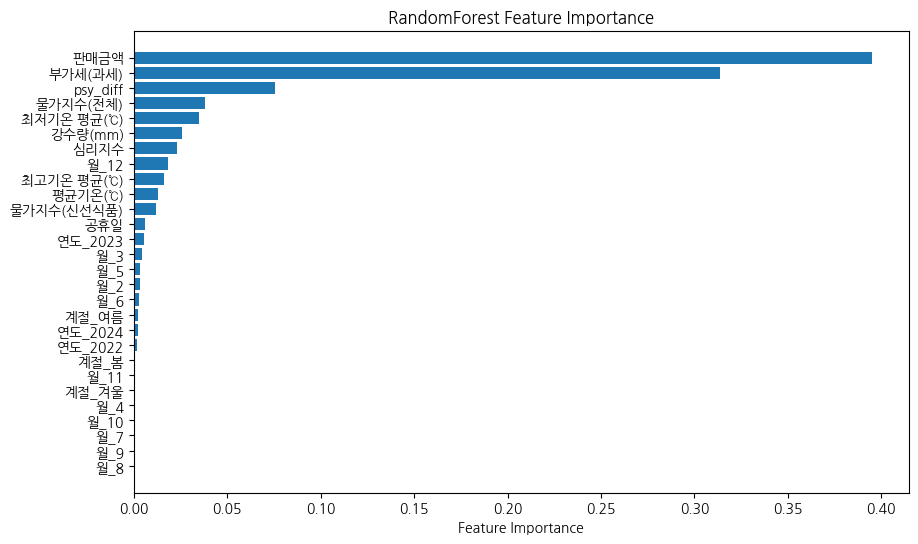

In [488]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#====5-Fold CV====
rf = RandomForestRegressor(random_state=42)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_rmse = cross_val_score(
    rf, X_train, y_train, scoring="neg_root_mean_squared_error", cv=cv
)

cv_scores_r2 = cross_val_score(
    rf, X_train, y_train, scoring="r2", cv=cv
)

print("===== 5-Fold CV 결과 (Train Set) =====")
print(f"RMSE (평균): {(-cv_scores_rmse.mean()):.4f}")
print(f"R2   (평균): {(cv_scores_r2.mean()):.4f}")

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n===== Test Set 평가 =====")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2:.4f}")


#====Feature Importance 정의 및 시각화====
importances = rf.feature_importances_
feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\n===== Feature Importance =====")
print(feature_importances)

plt.figure(figsize=(10, 6))
plt.barh(feature_importances["Feature"], feature_importances["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("RandomForest Feature Importance")
plt.show()


In [489]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
y_test_pred = grid_search.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R2: {r2:.2f}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Test RMSE: 709.22
Test R2: 0.75


       Feature  Importance
0         판매금액    0.496094
1      부가세(과세)    0.412388
9     psy_diff    0.027444
8         심리지수    0.019407
2     물가지수(전체)    0.010011
3   물가지수(신선식품)    0.008682
6   최저기온 평균(℃)    0.005900
5   최고기온 평균(℃)    0.005371
4      평균기온(℃)    0.005058
10         공휴일    0.004016
7      강수량(mm)    0.003451
27       계절_여름    0.001441
12     연도_2023    0.000693
11     연도_2022    0.000045
14        월_10    0.000000
13     연도_2024    0.000000
16        월_12    0.000000
17         월_2    0.000000
18         월_3    0.000000
15        월_11    0.000000
19         월_4    0.000000
20         월_5    0.000000
22         월_7    0.000000
21         월_6    0.000000
23         월_8    0.000000
24         월_9    0.000000
25       계절_겨울    0.000000
26        계절_봄    0.000000


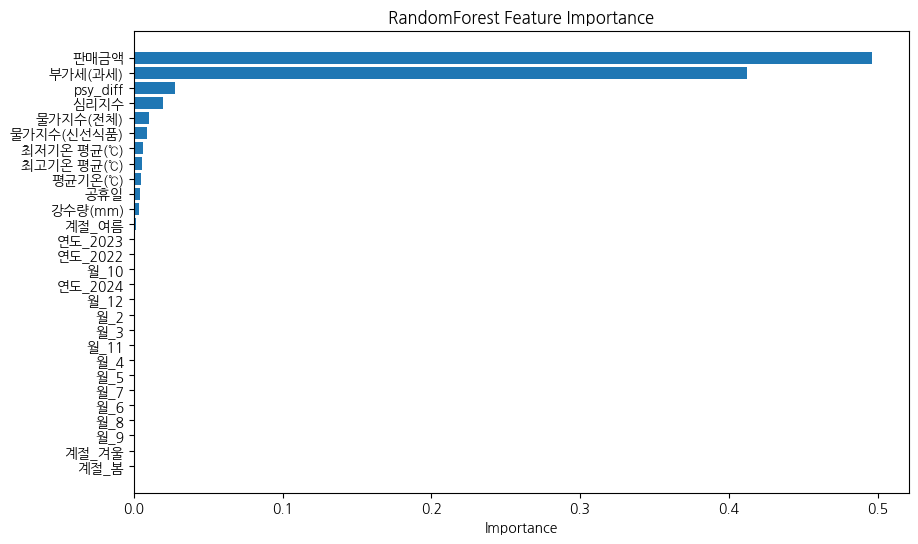

In [490]:
import pandas as pd
import matplotlib.pyplot as plt

best_rf = grid_search.best_estimator_

importances = best_rf.feature_importances_
feature_names = X_train.columns

# 데이터프레임
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp_df)

# 시각화
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'])
plt.gca().invert_yaxis()
plt.title("RandomForest Feature Importance")
plt.xlabel("Importance")
plt.show()

##A매입_생수,음료,건강

In [491]:
purchase_A_drinks_model = pd.read_csv('purchase_A_drinks_model.csv')

In [492]:
purchase_A_drinks_model.head()

,수량,판매금액,부가세(과세),물가지수(전체),"물가지수(생수,음료,건강)",평균기온(℃),최고기온 평균(℃),최저기온 평균(℃),강수량(mm),심리지수,...,월_3,월_4,월_5,월_6,월_7,월_8,월_9,계절_겨울,계절_봄,계절_여름
0,8794,18.357636,16.055051,101.04,101.0500,-0.5,4.9,-5.6,24.8,95.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,11330,18.294715,15.992130,101.58,100.8425,3.8,9.7,-1.6,22.5,97.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,18936,18.692435,16.389850,101.84,101.8125,8.9,14.9,3.5,113.0,100.6,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,16019,18.499248,16.196663,101.98,102.9650,13.2,19.3,7.5,77.2,102.5,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,17707,18.914782,16.612197,102.05,102.7775,16.7,22.3,11.6,138.6,105.7,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [493]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

In [494]:
#====X,y 피처 생성====
X = purchase_A_drinks_model.drop(columns=['수량'])
y = purchase_A_drinks_model['수량']

In [495]:
#====3가지 모델 성능 비교====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, eval_metric='rmse'),
    'LightGBM': lgb.LGBMRegressor(random_state=42, verbose=-1)
}

results = []
fitted_models = {}

In [496]:
for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        results.append({'Model': name, 'RMSE': rmse, 'R2': r2})
        fitted_models[name] = model
    except Exception as e:
        print(f"{name} 학습 중 오류 발생: {e}")

# 결과 DataFrame
results_df = pd.DataFrame(results)
print("=== 모델 성능 비교 ===")
print(results_df)

LightGBM 학습 중 오류 발생: Do not support special JSON characters in feature name.
=== 모델 성능 비교 ===
          Model         RMSE        R2
0  RandomForest  6647.373698  0.577662
1       XGBoost  8051.291573  0.380429


일반 모델을 돌렸을 때 RandomForest가 가장 좋은 성능을 보임 (RF > XGB > LGBM)

-> 이에 따라 RandomForest 모델을 5-fold cv를 사용하여 돌리고자 함

===== 5-Fold CV 결과 (Train Set) =====
RMSE (평균): 7274.7710
R2   (평균): 0.2958

===== Test Set 평가 =====
RMSE: 6647.3737
R2  : 0.5777

===== Feature Importance =====
           Feature  Importance
2         물가지수(전체)    0.287565
0             판매금액    0.168176
1          부가세(과세)    0.127447
3   물가지수(생수,음료,건강)    0.122613
7          강수량(mm)    0.080081
5       최고기온 평균(℃)    0.045017
13         연도_2024    0.037579
8             심리지수    0.024130
9         psy_diff    0.019654
6       최저기온 평균(℃)    0.018728
21             월_6    0.016763
4          평균기온(℃)    0.012211
26            계절_봄    0.008781
10             공휴일    0.008240
18             월_3    0.005910
12         연도_2023    0.005193
24             월_9    0.002301
16            월_12    0.002116
15            월_11    0.001113
20             월_5    0.001095
19             월_4    0.001014
11         연도_2022    0.000899
22             월_7    0.000653
27           계절_여름    0.000638
17             월_2    0.000578
23             월_8    0.000551
2

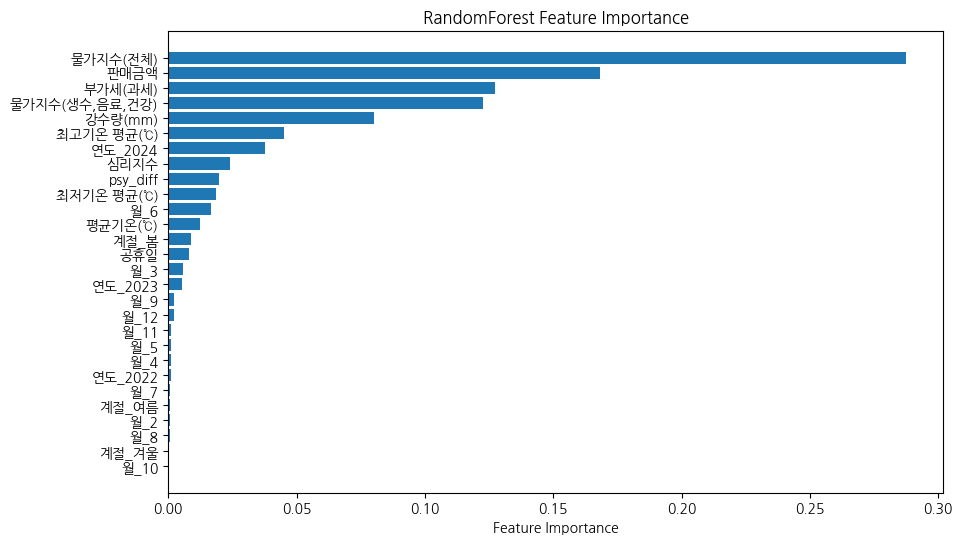

In [497]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#====5-Fold CV====
rf = RandomForestRegressor(random_state=42)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_rmse = cross_val_score(
    rf, X_train, y_train, scoring="neg_root_mean_squared_error", cv=cv
)

cv_scores_r2 = cross_val_score(
    rf, X_train, y_train, scoring="r2", cv=cv
)

print("===== 5-Fold CV 결과 (Train Set) =====")
print(f"RMSE (평균): {(-cv_scores_rmse.mean()):.4f}")
print(f"R2   (평균): {(cv_scores_r2.mean()):.4f}")

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n===== Test Set 평가 =====")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2:.4f}")


#====Feature Importance 정의 및 시각화====
importances = rf.feature_importances_
feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\n===== Feature Importance =====")
print(feature_importances)

plt.figure(figsize=(10, 6))
plt.barh(feature_importances["Feature"], feature_importances["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("RandomForest Feature Importance")
plt.show()


In [498]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
y_test_pred = grid_search.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R2: {r2:.2f}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Test RMSE: 6755.42
Test R2: 0.56


           Feature  Importance
2         물가지수(전체)    0.276596
3   물가지수(생수,음료,건강)    0.153115
0             판매금액    0.147824
1          부가세(과세)    0.130839
7          강수량(mm)    0.070466
5       최고기온 평균(℃)    0.043092
13         연도_2024    0.033727
8             심리지수    0.030639
6       최저기온 평균(℃)    0.020934
4          평균기온(℃)    0.019188
9         psy_diff    0.019111
21             월_6    0.013265
10             공휴일    0.009118
26            계절_봄    0.006279
12         연도_2023    0.004772
18             월_3    0.003878
16            월_12    0.003846
24             월_9    0.003060
15            월_11    0.002584
22             월_7    0.001904
27           계절_여름    0.001373
14            월_10    0.001058
19             월_4    0.001052
20             월_5    0.000638
25           계절_겨울    0.000525
11         연도_2022    0.000476
17             월_2    0.000327
23             월_8    0.000314


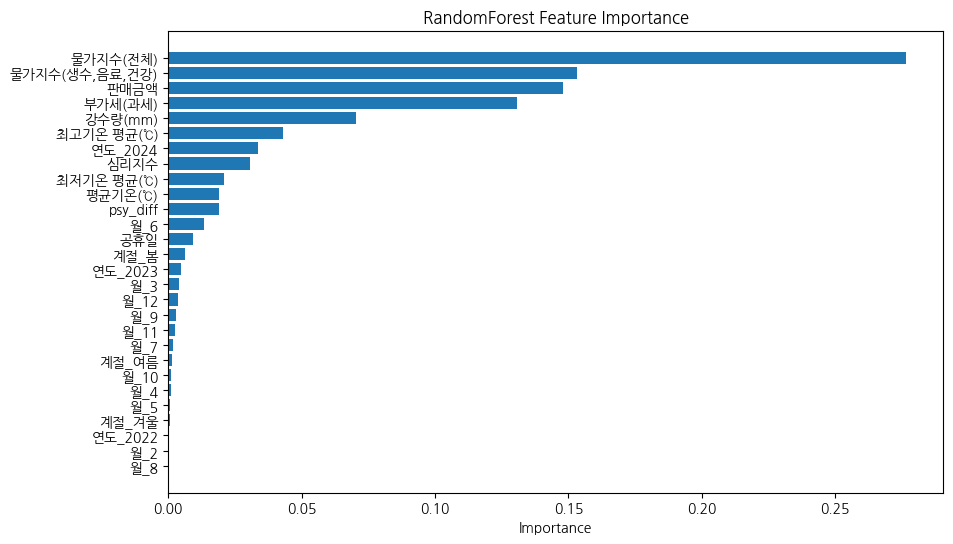

In [499]:
import pandas as pd
import matplotlib.pyplot as plt

best_rf = grid_search.best_estimator_

importances = best_rf.feature_importances_
feature_names = X_train.columns

# 데이터프레임
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp_df)

# 시각화
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'])
plt.gca().invert_yaxis()
plt.title("RandomForest Feature Importance")
plt.xlabel("Importance")
plt.show()

## A매출_신선식품

In [500]:
sales_A_fresh_model = pd.read_csv("sales_A_fresh_model.csv")

In [501]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

X = sales_A_fresh_model.drop(columns=['판매수량'])
y = sales_A_fresh_model['판매수량']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, eval_metric='rmse'),
    'LightGBM': lgb.LGBMRegressor(random_state=42, verbose=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results)
print(results_df)

          Model      RMSE        R2
0  RandomForest  0.012790  0.999610
1       XGBoost  0.015846  0.999402
2      LightGBM  0.651351 -0.011273


RandomForest 성능이 가장 좋음 -> 하이퍼파라미터 튜닝 진행

In [502]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)


grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
y_pred = grid_search.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R2: {r2:.2f}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Test RMSE: 0.02
Test R2: 1.00


## A매출_생수,음료,건강

In [503]:
sales_A_drinks_model = pd.read_csv("sales_A_drinks_model.csv")

In [504]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

X = sales_A_drinks_model.drop(columns=['판매수량'])
y = sales_A_drinks_model['판매수량']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, eval_metric='rmse'),
    'LightGBM': lgb.LGBMRegressor(random_state=42, verbose=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results)
print(results_df)

          Model      RMSE        R2
0  RandomForest  0.006373  0.999925
1       XGBoost  0.009583  0.999830
2      LightGBM  0.739543 -0.010461


In [505]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)


grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
y_pred = grid_search.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R2: {r2:.2f}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Test RMSE: 0.01
Test R2: 1.00


## B매입_라면

In [506]:
purchase_B_ramen_model = pd.read_csv("purchase_B_ramen_model.csv")

In [507]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

X = purchase_B_ramen_model.drop(columns=['수량'])
y = purchase_B_ramen_model['수량']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, eval_metric='rmse'),
    'LightGBM': lgb.LGBMRegressor(random_state=42, verbose=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results)
print(results_df)

          Model         RMSE        R2
0  RandomForest  1284.061266  0.900909
1       XGBoost  1611.108081  0.844005
2      LightGBM  4090.721600 -0.005685


RandomForest의 성능이 가장 좋음, 하이퍼파라미터 튜닝 진행

In [508]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
y_test_pred = grid_search.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R2: {r2:.2f}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Test RMSE: 1282.94
Test R2: 0.90


       Feature  Importance
0         판매금액    0.473970
1      부가세(과세)    0.399113
2         물가지수    0.030571
3     물가지수(라면)    0.020592
9     psy_diff    0.014074
8         심리지수    0.010017
7      강수량(mm)    0.010000
10         공휴일    0.007098
6   최저기온 평균(℃)    0.004098
4      평균기온(℃)    0.003670
11     연도_2022    0.003583
13     연도_2024    0.003403
18         월_3    0.003183
5   최고기온 평균(℃)    0.003134
14        월_10    0.002955
12     연도_2023    0.002834
24         월_9    0.001288
22         월_7    0.001084
15        월_11    0.000899
20         월_5    0.000720
25       계절_겨울    0.000634
21         월_6    0.000631
16        월_12    0.000613
27       계절_여름    0.000593
26        계절_봄    0.000500
17         월_2    0.000408
19         월_4    0.000291
23         월_8    0.000046


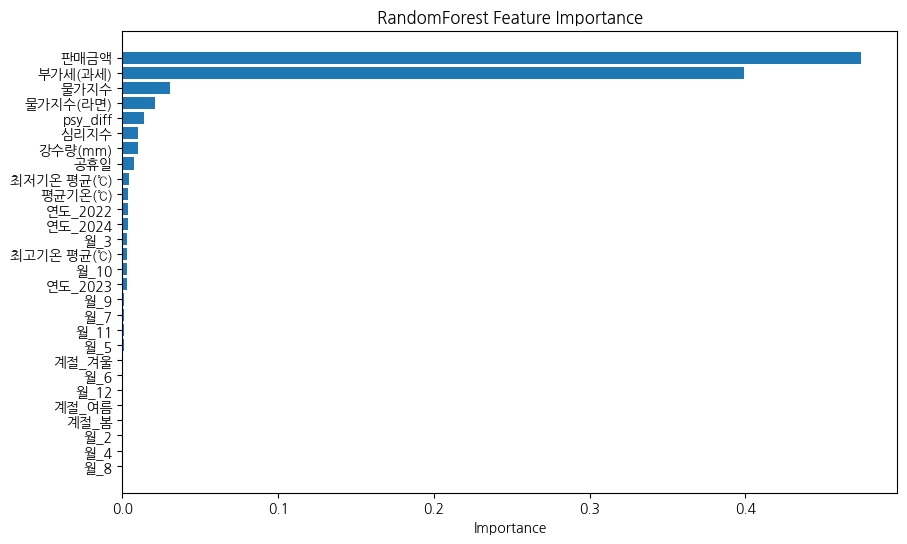

In [509]:
import pandas as pd
import matplotlib.pyplot as plt

best_rf = grid_search.best_estimator_

importances = best_rf.feature_importances_
feature_names = X_train.columns

# 데이터프레임
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp_df)

# 시각화
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'])
plt.gca().invert_yaxis()
plt.title("RandomForest Feature Importance")
plt.xlabel("Importance")
plt.show()

## B매입_탄산음료

In [510]:
purchase_B_drinks_model = pd.read_csv("purchase_B_drinks_model.csv")

In [511]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

X = purchase_B_drinks_model.drop(columns=['수량'])
y = purchase_B_drinks_model['수량']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, eval_metric='rmse'),
    'LightGBM': lgb.LGBMRegressor(random_state=42, verbose=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results)
print(results_df)

          Model         RMSE        R2
0  RandomForest  1971.611024  0.846498
1       XGBoost  2201.390697  0.808634
2      LightGBM  5049.097068 -0.006696


RandomForest의 성능이 가장 좋음, 하이퍼파라미터 튜닝 진행

In [512]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)


grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
y_pred = grid_search.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R2: {r2:.2f}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Test RMSE: 1804.89
Test R2: 0.87


       Feature  Importance
0         판매금액    0.452857
1      부가세(과세)    0.421518
6   최저기온 평균(℃)    0.019356
9     psy_diff    0.014876
8         심리지수    0.013534
7      강수량(mm)    0.013421
4      평균기온(℃)    0.013308
5   최고기온 평균(℃)    0.012894
2         물가지수    0.008731
3     물가지수(탄산)    0.008715
27       계절_여름    0.005731
11     연도_2022    0.002596
10         공휴일    0.002481
16        월_12    0.002359
26        계절_봄    0.002089
20         월_5    0.000891
22         월_7    0.000831
25       계절_겨울    0.000703
13     연도_2024    0.000661
23         월_8    0.000404
24         월_9    0.000378
17         월_2    0.000377
12     연도_2023    0.000337
18         월_3    0.000251
15        월_11    0.000219
14        월_10    0.000189
19         월_4    0.000167
21         월_6    0.000124


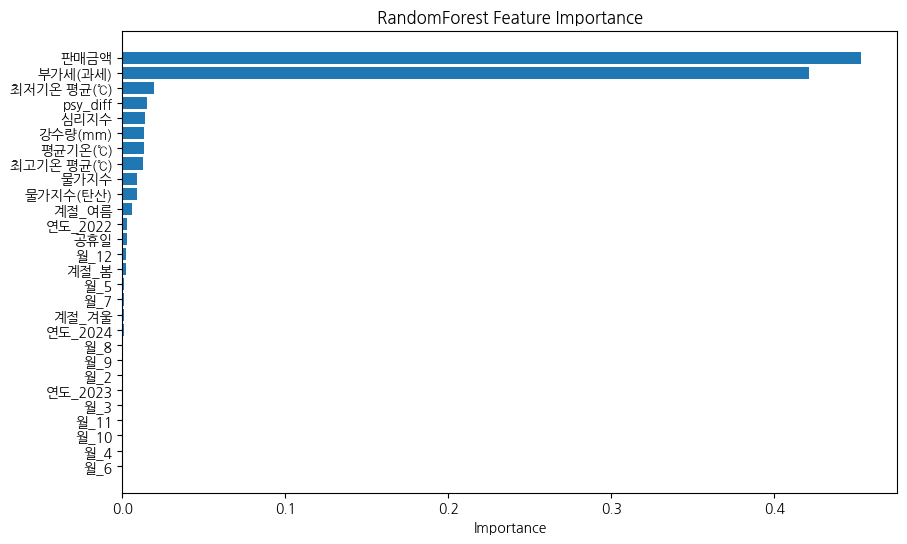

In [513]:
import pandas as pd
import matplotlib.pyplot as plt

best_rf = grid_search.best_estimator_

importances = best_rf.feature_importances_
feature_names = X_train.columns

# 데이터프레임
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp_df)

# 시각화
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'])
plt.gca().invert_yaxis()
plt.title("RandomForest Feature Importance")
plt.xlabel("Importance")
plt.show()